In [ ]:
from matplotlib import cm
from netCDF4 import Dataset 
import numpy as np 
import math
import scipy.stats as stats 
import matplotlib.pyplot as plot
from matplotlib.pyplot import MultipleLocator
from scipy import signal
# import seaborn
import seaborn as sns
import datetime
import calendar
from sklearn import preprocessing


In [2]:
dt = 2*60
total_seconds = 248 * 100000 * 86400
mmax = total_seconds // dt
myear = mmax // 100000
mout = int(0.775 * 86400 / dt)*5
msize = mmax // mout


print(myear,mmax, mout, msize)


178560 17856000000 2790 6400000


In [ ]:
#-----------------
# read netCDF files
#-----------------

#filename1 = 'ur60n10hPa.nc'
#filename2 = 'ub60n10hPa.nc'
filename1 = '/scratch/smliu01/1d_model/archive/ur60n10hPa.nc'
filename2 = '/scratch/smliu01/1d_model/archive/ub60n10hPa.nc'

ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
ncin2 = Dataset(filename2, 'r', format='NETCDF4')

uref = ncin1.variables['uref'] 
uref = (np.array(uref))
ubar = ncin2.variables['ubar'] 
ubar = (np.array(ubar))
print(uref.shape)
print(ubar.shape)

i=0
urp = np.zeros((42,992))
ubp = np.zeros((42,992))
days = np.zeros(8)
dddd = np.zeros((42,992))
date = dddd.tolist()

month = [9,10,11,0,1,2,3,4]

time = ['00','06','12','18']
months = ['10','11','12','01','02','03','04','05']
dates = ['01','02','03','04','05','06','07','08','09','10',   \
         '11','12','13','14','15','16','17','18','19',        \
        '20','21','22','23','24','25','26','27','28','29','30','31']

while(i<42):
    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if uref[j,month[m],i]!=0:
                    urp[i,k] = uref[j,month[m],i]
                    date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            else:
                if uref[j,month[m],i+1]!=0:
                    urp[i,k] = uref[j,month[m],i+1]
                    date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #urp[urp==0]=np.nan


    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if ubar[j,month[m],i]!=0:
                    ubp[i,k] = ubar[j,month[m],i]
                    k=k+1
            else:
                if ubar[j,month[m],i+1]!=0:
                    ubp[i,k] = ubar[j,month[m],i+1]
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #ubp[ubp==0]=np.nan

    i=i+1


print(ubp.shape)

#-----------------
# read netCDF files
#-----------------

#filename1 = 'ur60n10hPa.nc'
#filename2 = 'ub60n10hPa.nc'
filename1 = '/scratch/smliu01/1d_model/archive/tr60n10hPa.nc'
filename2 = '/scratch/smliu01/1d_model/archive/tb60n10hPa.nc'

ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
ncin2 = Dataset(filename2, 'r', format='NETCDF4')

tref = ncin1.variables['tref'] 
tref = (np.array(tref))
tbar = ncin2.variables['tbar'] 
tbar = (np.array(tbar))
print(tref.shape)
print(tbar.shape)

i=0
trp = np.zeros((42,992))
tbp = np.zeros((42,992))
days = np.zeros(8)
dddd = np.zeros((42,992))
date = dddd.tolist()

month = [9,10,11,0,1,2,3,4]

time = ['00','06','12','18']
months = ['10','11','12','01','02','03','04','05']
dates = ['01','02','03','04','05','06','07','08','09','10',   \
         '11','12','13','14','15','16','17','18','19',        \
        '20','21','22','23','24','25','26','27','28','29','30','31']

while(i<42):
    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if tref[j,month[m],i]!=0:
                    trp[i,k] = tref[j,month[m],i]
                    date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            else:
                if tref[j,month[m],i+1]!=0:
                    trp[i,k] = tref[j,month[m],i+1]
                    date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #urp[urp==0]=np.nan


    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if tbar[j,month[m],i]!=0:
                    tbp[i,k] = tbar[j,month[m],i]
                    k=k+1
            else:
                if tbar[j,month[m],i+1]!=0:
                    tbp[i,k] = tbar[j,month[m],i+1]
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #ubp[ubp==0]=np.nan

    i=i+1


print(tbp.shape)


dmax = 716

ueast = np.zeros((42,dmax))
ratiosl = np.zeros((42,dmax))

onset = np.zeros((42,dmax))
ronset = np.zeros((42,dmax))

onset_id = np.zeros(200)
ronset_id = np.zeros(210)

end = np.zeros((42,dmax))
rend = np.zeros((42,dmax))

end_id = np.zeros(200)
rend_id = np.zeros(210)

ssw = np.zeros((42,dmax))
rssw = np.zeros((42,dmax))

fponset_id = np.zeros(210)

ratio = 0.3

######################################### find out the onset date #######################################

i = 0
while(i < 42):
    j = 0
    while(j < dmax):
        if ubp[i,j] < 0:
            ueast[i,j] = 1 
        if ubp[i,j]/urp[i,j] < ratio:
            ratiosl[i,j] = 1
        j=j+1
    i=i+1

i = 0
n = 0
nn = 0
m = 0
mm = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax):
        if ubp[i,j] < 0 and ueast[i,j-1] == 0:
            onset[i,j] = 1
            onset_id[n] = t
            n=n+1
            #print(date[i][j])
        elif ubp[i,j] > 0 and ueast[i,j-1] == 1:
            end[i,j] = 1
            end_id[m] = t
            m=m+1
        elif j == dmax-1:
            if ueast[i,j] == 1:
                end[i,j] = 1
                end_id[m] = t
                m=m+1
        if ubp[i,j]/urp[i,j] < ratio and ratiosl[i,j-1] == 0: 
            ronset[i,j] = 1
            ronset_id[nn] = t
            nn=nn+1
        elif ubp[i,j]/urp[i,j] > ratio and ratiosl[i,j-1] == 1: 
            rend[i,j] = 1
            rend_id[mm] = t
            mm=mm+1
        elif j == dmax-1:
            if ratiosl[i,j] == 1:
                rend[i,j] = 1
                rend_id[mm] = t
                mm=mm+1
        t=t+1
        j=j+1
    i=i+1


######################################### exclude some events #######################################

n = 1
while(n<210):
    if rend_id[n]-ronset_id[n]<2*4:
        ronset_id[n]=0
        rend_id[n]=0        
    n=n+1


#the interval of the start of an event and the end of the last event should be larger than 10 days
n = 1
while(n<200):
    if (onset_id[n]-end_id[n-1])<10*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1 
n = 2
while(n<200):
    if (onset_id[n]-end_id[n-2])<10*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1

n = 1
while(n<210):
    if (ronset_id[n]-rend_id[n-1])<10*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1 
n = 2
while(n<210):
    if (ronset_id[n]-rend_id[n-2])<10*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1

#there shouldn't be a new event shorter than 20 days
n = 1
while(n<200):
    if onset_id[n]-onset_id[n-1]<20*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1

n = 3
while(n<210):
    if ronset_id[n]-ronset_id[n-3]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1

n = 2
while(n<210):
    if ronset_id[n]-ronset_id[n-2]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1
    
n = 1
while(n<210):
    if ronset_id[n]-ronset_id[n-1]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1  

#the event lasts till the end should be excluded
n = 1
while(n<200):
    if end_id[n]%(dmax-1)==0:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1

n = 1
while(n<210):
    if rend_id[n]%(dmax-1)==0:
        ronset_id[n]=0
        rend_id[n]=0        
    n=n+1

#an event should at least be longer than 2 days
n = 1
while(n<200):
    if end_id[n]-onset_id[n]<2*4:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1


#exclude 3 events
n = 1
while(n<200):
    if onset_id[n]==6380 or onset_id[n]==18525 or onset_id[n]==22145:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1

    
fp=0
tp=0
fn=0
fpb=0

######################################### print out the date #######################################

barplot = np.zeros(6)

i = 0
n = 0
c = 0
while(i < 42):
    j = 1
    while(j < dmax):
        if onset[i,j] == 1:      #ubar<0
            if onset_id[n] == 0: #ubar<0 but there's no SSW
                True
            else:                #there is an SSW
                print(date[i][j])
                
                if date[i][j][5:7] == '11':
                    barplot[0] = barplot[0]+1
                elif date[i][j][5:7] == '12':
                    barplot[1] = barplot[1]+1
                elif date[i][j][5:7] == '01':
                    barplot[2] = barplot[2]+1
                elif date[i][j][5:7] == '02':
                    barplot[3] = barplot[3]+1                    
                elif date[i][j][5:7] == '03':
                    barplot[4] = barplot[4]+1                     
                elif date[i][j][5:7] == '04':
                    barplot[5] = barplot[5]+1                     
                
                if ubp[i,j-2]/urp[i,j-2] < ratio: #find out true positive
                    tp=tp+1
#                if ubp[i,j]/urp[i,j] > ratio: #find out false negative
#                    fn=fn+1                
                c=c+1            #how many SSWs
            n=n+1                #the size of onset_id        
        j=j+1
    i=i+1

print('####################################')

i = 0
nn = 0
cc = 0
while(i < 42):
    j = 1
    while(j < dmax): 
        if ronset[i,j] == 1:      #ubar/uref<0.3
            if ronset_id[nn] == 0: #ubar/uref<0.3 but there's no SSW
                True
            else:
                #print(date[i][j])
                cc=cc+1            #how many rSSWs
            nn=nn+1                #the size of onset_id       
        j=j+1
    i=i+1


    
######################################### mark each day of ssw #######################################
i = 0
n = 0
nn = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax):       
        if t>=onset_id[n] and t<=end_id[n]:
            ssw[i,j] = 1
        if end[i,j]==1:
            n=n+1                #the size of onset_id   
        if t>=ronset_id[nn] and t<=rend_id[nn]:
            rssw[i,j] = 1
        if rend[i,j]==1:
            nn=nn+1                #the size of onset_id  
        t=t+1
        j=j+1
    i=i+1
    
print('####################################')
######################################### find out false positive #######################################
nn = 0
fponset_id=ronset_id
while(nn < 210):
    n = 0
    while(n < 200):
        if onset_id[n]>ronset_id[nn] and onset_id[n]<rend_id[nn]: #exclude onset happen between <0.3 start and end
            fponset_id[nn]=0
        elif abs(onset_id[n]-ronset_id[nn])<40: #exclude 0.3 and onset too far way
            fponset_id[nn]=0
        n=n+1
    nn=nn+1

i = 0
n = 0
nn = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax): 
        if ronset[i,j] == 1: 
            if fponset_id[nn] != 0:      #ubar/uref<0.3
                fp=fp+1
                if ubp[i,j+5]<ubp[i,j]:
                    fpb=fpb+1
            nn=nn+1
        j=j+1
    i=i+1


print('true positive:'+str(tp))
print('total ssws amount:'+str(c))
print('false positive:'+str(fp))
print('false positive but vortex decreasing:'+str(fpb))




height = np.zeros(97)
plev = np.zeros(97)
h1d = np.zeros(381)
dz = 500.
hh = 7000.
dz1d = 100
for k in range(97):
    height[k] = k*dz
    plev[k] = 1000*np.exp(-height[k]/hh)
for k in range(381):
    h1d[k] = dz1d*k+10000.

print(height[96])
print(h1d[0])

filename1 = '/scratch/smliu01/1d_model/archive/ana60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz = ncin1.variables['epz'] 
epz = (np.array(epz))
fawa = ncin1.variables['fawa'] 
fawa = (np.array(fawa))
ubar = ncin1.variables['ubar'] 
ubar = (np.array(ubar))
uref = ncin1.variables['uref'] 
uref = (np.array(uref))


filename1 = '/scratch/smliu01/1d_model/archive/tran60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz_tran = ncin1.variables['epz'] 
epz_tran = (np.array(epz_tran))
fawa_tran = ncin1.variables['fawa'] 
fawa_tran = (np.array(fawa_tran))
ubar_tran = ncin1.variables['ubar'] 
ubar_tran = (np.array(ubar_tran))
uref_tran = ncin1.variables['uref'] 
uref_tran = (np.array(uref_tran))
print(epz.shape)

file = '/scratch/smliu01/1d_model/archive/sea60n.nc'
ncin1 = Dataset(file, 'r', format='NETCDF4') 
fawa_sea = ncin1.variables['fawa'] 
fawa_sea = (np.array(fawa_sea))
ubar_sea = ncin1.variables['ubar'] 
ubar_sea = (np.array(ubar_sea))
uref_sea = ncin1.variables['uref']
uref_sea = (np.array(uref_sea))
epz_sea = ncin1.variables['epz'] 
epz_sea = (np.array(epz_sea))
print(fawa_sea.shape)

fawa_sea_n = np.zeros((97, 124, 12, 43))
ubar_sea_n = np.zeros((97, 124, 12, 43))
uref_sea_n = np.zeros((97, 124, 12, 43))
epz_sea_n = np.zeros((97, 124, 12, 43))

for i in range(43):
    fawa_sea_n[:,:,:,i] = fawa_sea[:,:,:]
    ubar_sea_n[:,:,:,i] = ubar_sea[:,:,:]
    uref_sea_n[:,:,:,i] = uref_sea[:,:,:]
    epz_sea_n[:,:,:,i] = epz_sea[:,:,:]


def Oct_to_May(vv):

    i=0
    vbar = np.zeros((97,42,992))
    days = np.zeros(8)
    dddd = np.zeros((42,992))
    date = dddd.tolist()

    month = [9,10,11,0,1,2,3,4]

    time = ['00','06','12','18']
    months = ['10','11','12','01','02','03','04','05']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<8):
                j=0
                while(j<124):
                    if m<3:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def Nov_to_Mar(vv):

    i=0
    vbar = np.zeros((97,42,604))
    days = np.zeros(5)
    dddd = np.zeros((42,604))
    date = dddd.tolist()

    month = [10,11,0,1,2]

    time = ['00','06','12','18']
    months = ['11','12','01','02','03']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<5):
                j=0
                while(j<124):
                    if m<2:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def sixty_to_sixty(onset_id,dmax,vbar):

    yy=0

    vb = np.zeros((97,22,121*4))

    i=0
    while(i<42):
        for n in range(onset_id.shape[0]):
            if onset_id[n]!=0:
                if int((onset_id[n]+(dmax-1))/(dmax-1))-1==i:
                    kk = onset_id[n]-(dmax-1)*i
                    #print(n,kk)
                    for k in range(int(kk-60*4),int(kk+61*4)):
                        z=0
                        while(z<97):
                            x = int(abs(k-kk+60*4))
                            #print(x)
                            vb[z,yy,x] = vbar[z,i,k]  #################################
                            z=z+1
                    yy = yy+1
        i=i+1
        
    return vb

uref_eachyr = Oct_to_May(uref)
ubar_eachyr = Oct_to_May(ubar)
fawa_eachyr = Oct_to_May(fawa)
epz_eachyr = Oct_to_May(epz)


print('done')




(124, 12, 43)
(124, 12, 43)


(42, 992)
(124, 12, 43)
(124, 12, 43)
(42, 992)
1980/02/29/00
1981/12/04/00
1984/02/23/18
1984/12/31/18
1987/01/22/18
1987/12/08/00
1989/02/21/00
1998/12/15/06
1999/02/25/18
2000/03/19/18
2001/02/11/06
2001/12/30/12
2004/01/04/18
2006/01/21/00
2007/02/24/00
2008/02/21/18
2009/01/24/06
2010/02/09/00
2013/01/06/12
2018/02/11/18
2019/01/19/18
2021/01/05/00
####################################
####################################
true positive:22
total ssws amount:22
false positive:44
false positive but vortex decreasing:39
48000.0
10000.0
(97, 124, 12, 43)
(97, 124, 12)
done


In [4]:
model = 'ctl'

In [5]:
file = '/scratch/smliu01/1d_model/climatechange/forcing/'+model+'/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
ubar = ncin.variables['ubar']
ubar = np.array(ubar)
ncin.close()
print(ubar.shape)

file = '/scratch/smliu01/1d_model/climatechange/forcing/'+model+'/aout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
fawa = ncin.variables['fawa']
fawa = np.array(fawa)
ncin.close()
print(fawa.shape)

file = '/scratch/smliu01/1d_model/climatechange/forcing/'+model+'/urout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
uref = ncin.variables['uref']
uref = np.array(uref)
ncin.close()
print(uref.shape)

file = '/scratch/smliu01/1d_model/climatechange/forcing/'+model+'/fzout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
fz = ncin.variables['fz']
fz = np.array(fz)
ncin.close()
print(fz.shape)

height = np.zeros(97)
plev = np.zeros(97)
h1d = np.zeros(381)
dz = 500.
hh = 7000.
dz1d = 100
for k in range(97):
    height[k] = k*dz
    plev[k] = 1000*np.exp(-height[k]/hh)
for k in range(381):
    h1d[k] = dz1d*k+10000.

print(height[96])
print(h1d[0])

hhh = np.arange(0,1001,1)*0.1+10.

yr = 1000   # 42 for 42 years, 10 for 10 years

# # Reshape ubar, fawa, uref to (1001, 42, 320)
ubar_eachyear = ubar.reshape((501, yr, 160))
fawa_eachyear = fawa.reshape((501, yr, 160))
uref_eachyear = uref.reshape((501, yr, 160))
fz_eachyear = fz.reshape((501, yr, 160))

for i in range(501):
    fz_eachyear[i,:,:] = fz_eachyear[i,:,:]#/np.exp(-hhh[i]*1000/hh)


FileNotFoundError: [Errno 2] No such file or directory: '/scratch/smliu01/1d_model/climatechange/forcing/ctl/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc'

In [ ]:
# file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/uout_real_urad_0.nc'
# ncin = Dataset(file, 'r', format='NETCDF4')
# ubar = ncin.variables['ubar']
# ubar = np.array(ubar)
# ncin.close()
# print(ubar.shape)

# file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/aout_real_urad_0.nc'
# ncin = Dataset(file, 'r', format='NETCDF4')
# fawa = ncin.variables['fawa']
# fawa = np.array(fawa)
# ncin.close()
# print(fawa.shape)

# file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/urout_real_urad_0.nc'
# ncin = Dataset(file, 'r', format='NETCDF4')
# uref = ncin.variables['uref']
# uref = np.array(uref)
# ncin.close()
# print(uref.shape)

# file = '/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/fzout_real_urad_0.nc'
# ncin = Dataset(file, 'r', format='NETCDF4')
# fz = ncin.variables['fz']
# fz = np.array(fz)
# ncin.close()
# print(fz.shape)

# height = np.zeros(97)
# plev = np.zeros(97)
# h1d = np.zeros(381)
# dz = 500.
# hh = 7000.
# dz1d = 100
# for k in range(97):
#     height[k] = k*dz
#     plev[k] = 1000*np.exp(-height[k]/hh)
# for k in range(381):
#     h1d[k] = dz1d*k+10000.

# print(height[96])
# print(h1d[0])

# hhh = np.arange(0,1001,1)*0.1+10.



# # # Reshape ubar, fawa, uref to (1001, 42, 320)
# ubar_eachyear = ubar.reshape((1001, 42, 320))
# fawa_eachyear = fawa.reshape((1001, 42, 320))
# uref_eachyear = uref.reshape((1001, 42, 320))
# fz_eachyear = fz.reshape((1001, 42, 320))

# for i in range(1001):
#     fz_eachyear[i,:,:] = fz_eachyear[i,:,:]#/np.exp(-hhh[i]*1000/hh)




In [ ]:
# # Interpolate fawa, ubar, and uref to 992 dimensions
# from scipy.interpolate import interp1d

# # Get current dimensions
# current_dim = fawa.shape[1]
# target_dim = 992

# # Create interpolation function
# x_old = np.linspace(0, 1, current_dim)
# x_new = np.linspace(0, 1, target_dim)

# # Interpolate fawa to 992 dimensions
# fawa_interp = np.zeros((fawa.shape[0], target_dim))
# for i in range(fawa.shape[0]):
#     f_interp = interp1d(x_old, fawa[i,:], kind='linear', bounds_error=False, fill_value='extrapolate')
#     fawa_interp[i,:] = f_interp(x_new)

# # Interpolate ubar to 992 dimensions
# ubar_interp = np.zeros((ubar.shape[0], target_dim))
# for i in range(ubar.shape[0]):
#     u_interp = interp1d(x_old, ubar[i,:], kind='linear', bounds_error=False, fill_value='extrapolate')
#     ubar_interp[i,:] = u_interp(x_new)

# # Interpolate uref to 992 dimensions
# uref_interp = np.zeros((uref.shape[0], target_dim))
# for i in range(uref.shape[0]):
#     ur_interp = interp1d(x_old, uref[i,:], kind='linear', bounds_error=False, fill_value='extrapolate')
#     uref_interp[i,:] = ur_interp(x_new)

# # Create three separate plots
# fig, (ax1, ax2, ax3) = plot.subplots(3, 1, figsize=(10, 12))

# # Plot fawa
# ax1.plot(fawa_interp[220,0:], label='fawa Interpolated (992)')
# ax1.plot(fawa_eachyr[64,0,:], label='fawa_eachyr')
# ax1.set_title('fawa Comparison')
# ax1.legend()

# # Plot ubar
# ax2.plot(ubar_interp[220,:], label='ubar Interpolated (992)')
# ax2.plot(ubar_eachyr[64,0,:], label='ubar_eachyr')
# ax2.set_title('ubar Comparison')
# ax2.legend()

# # Plot uref
# ax3.plot(uref_interp[220,:], label='uref Interpolated (992)')
# ax3.plot(uref_eachyr[64,0,:], label='uref_eachyr')
# ax3.set_title('uref Comparison')
# ax3.legend()

# plot.tight_layout()


In [ ]:
from netCDF4 import Dataset

files = {
    "forcing": "/scratch/smliu01/1d_model/climatechange/forcing/ctl/forcing_total_1000_ctl.nc",
    "urad": "/scratch/smliu01/1d_model/climatechange/urad_below32_fit_above32_HMshear_501_1000.nc",
    "init": "/scratch/smliu01/1d_model/init_501_1000.nc",
}

for name, path in files.items():
    print("\n", name, path)
    with Dataset(path) as ds:
        for v in ds.variables:
            print(v, ds.variables[v].shape)


 forcing /scratch/smliu01/1d_model/climatechange/forcing/ctl/forcing_total_1000_ctl.nc
forcing (1000, 992)

 urad /scratch/smliu01/1d_model/climatechange/urad_below32_fit_above32_HMshear_501_1000.nc
height (501,)
year (1000,)
time (992,)
urad (501, 1000, 992)

 init /scratch/smliu01/1d_model/init_501_1000.nc
fawa (501, 1000)
ubar (501, 1000)
uref (501, 1000)


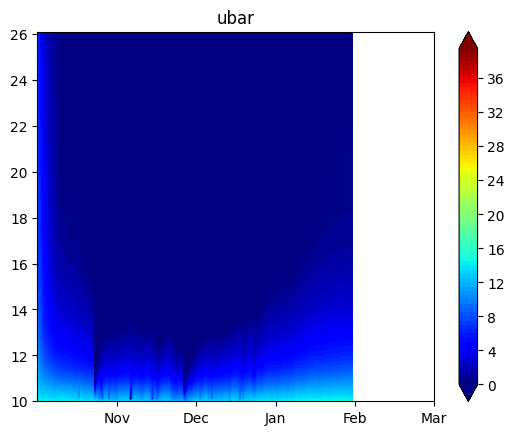

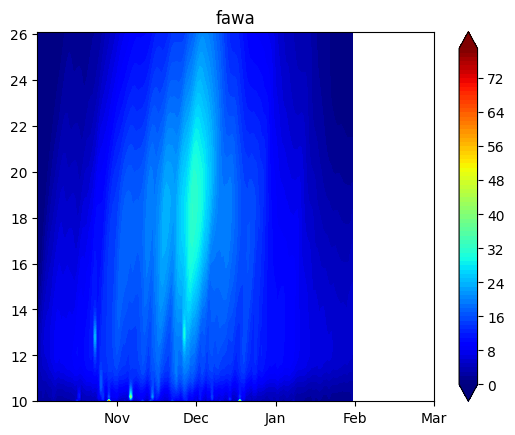

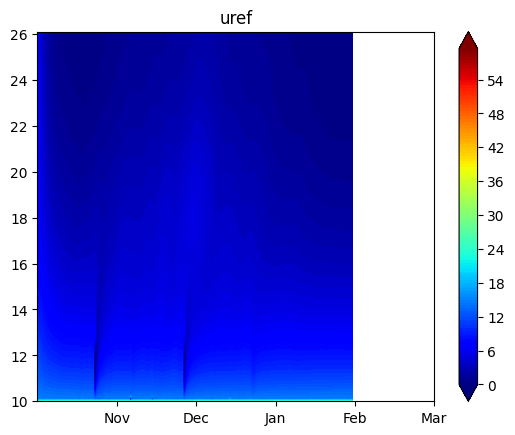

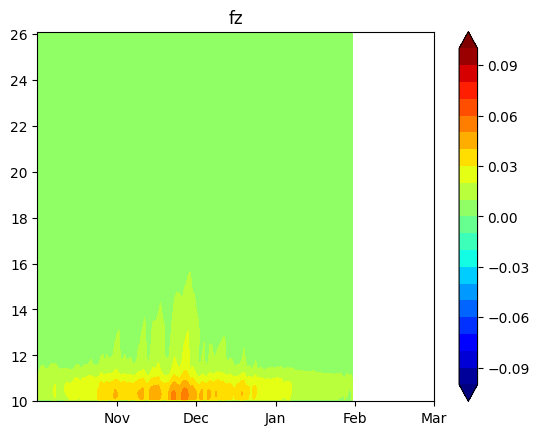

In [ ]:
xx = np.arange(0,160,1) #*int(992/320)/4
zz = hhh

fig, ax = plot.subplots()
cf = ax.contourf(xx, zz[0:162], np.mean(ubar_eachyear[0:162,:,], axis=1), levels=np.arange(0, 40, 0.5), extend='both', cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('ubar')
plot.colorbar(cf, ax=ax)
plot.show()

fig, ax = plot.subplots()   
cf = ax.contourf(xx,zz[0:162],np.mean(fawa_eachyear[0:162,:,:],axis=1), levels=np.arange(0, 80, 1), extend='both',cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('fawa')
plot.colorbar(cf, ax=ax)
plot.show()

fig, ax = plot.subplots()
cf = ax.contourf(xx,zz[0:162],np.mean(uref_eachyear[0:162,:,],axis=1), levels=np.arange(0, 60, 0.5), extend='both', cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('uref')
plot.colorbar(cf, ax=ax)
plot.show()

fig, ax = plot.subplots()
cf = ax.contourf(xx,zz[0:162],np.mean(fz_eachyear[0:162,:,:],axis=1), levels=np.arange(-0.1, 0.11, 0.01),extend= 'both', cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('fz')
plot.colorbar(cf, ax=ax)
plot.show()


In [ ]:
import numpy as np

def model_ubar_to_era5_like_inputs(
    ubar_model,          # shape = (nz, years*steps_per_year)  (501, 13440)
    level_index=110,     # 100 hPa  z 
    years=yr, # 200,
    steps_per_year=160,  #  10–5 
    start_year=1979      #  ERA5  1979-10 
):
    """
    
      ubp:  shape = (years, 992)  6-hourly Oct–May 
      date: list[list[str]]'YYYY/MM/DD/HH' ubp 
    
      -  992 = 8  × 31  × 4 /
      - ['10','11','12','01','02','03','04','05']
         31 2  31 
         31×4=124  0 
      -  SSW 
    """
    nz, nt = ubar_model.shape
    assert nt == years * steps_per_year, " years*steps_per_year "

    #  100 hPa  reshape  (years, steps_per_year)
    u = np.array(ubar_model[level_index, :], dtype=float).reshape(years, steps_per_year)

    #  6-hourly  992 8  × 31  ×  4 
    tgt_len = 992
    src_x = np.arange(steps_per_year, dtype=float)
    tgt_x = np.linspace(0, steps_per_year - 1, tgt_len)

    ubp = np.empty((years, tgt_len), dtype=float)
    for y in range(years):
        #  1D 
        ubp[y] = np.interp(tgt_x, src_x, u[y])

    #  date list of list
    time4 = ['00', '06', '12', '18']
    months = ['10', '11', '12', '01', '02', '03', '04', '05']
    days31 = [f"{d:02d}" for d in range(1, 32)]  #  31 
    #  8  × 31  × 4 / = 992
    date = [[None]*tgt_len for _ in range(years)]
    for y in range(years):
        k = 0
        for mi, mm in enumerate(months):
            # 10/11/12  start_year+y01–05  start_year+y+1
            year_label = (start_year + y) if mi < 3 else (start_year + y + 1)
            for dd in days31:
                for hh in time4:
                    #  'YYYY/MM/DD/HH'
                    date[y][k] = f"{year_label}/{mm}/{dd}/{hh}"
                    k += 1
        assert k == tgt_len

    return ubp, date

# =====  =====
ubp_model, date_model = model_ubar_to_era5_like_inputs(ubar, level_index=110, years=yr, steps_per_year=160, start_year=1979)
#  ubp_model  ubp shape=(42,992)date_model 
#  uref urp_model


In [ ]:
import numpy as np

def count_ssw_events_from_ubar_legacy(
    u_all_flat,
    n_per_year,
    years,
    dmax_ref=716,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=10.0,
    use_djf_only=False,
    exclude_onset_indices=None,
    #  date 
    date_2d=None,
    #  3  10  onset 
    enforce_march10_cutoff=False,
    return_debug=False,
):
    """
     10 hPa u<0  SSW 

    
    -  enforce_march10_cutoff=True  date_2d
       onset  3  10 
    """

    u_all_flat = np.asarray(u_all_flat, dtype=float)
    assert u_all_flat.size == years * n_per_year, \
        f"u_all_flat ={u_all_flat.size},  years*n_per_year={years*n_per_year}"

    u_2d = u_all_flat.reshape(years, n_per_year)

    # =====  →  =====
    scale = n_per_year / float(dmax_ref)
    steps_per_day = 4.0 * scale

    min_gap_steps       = max(1, int(round(min_gap_days * steps_per_day)))
    min_gap_onset_steps = max(1, int(round(min_gap_onset_days * steps_per_day)))
    min_duration_steps  = max(1, int(round(min_duration_days * steps_per_day)))

    djf_start = None
    djf_end   = None

    # ===== DJF only  =====
    if use_djf_only:
        djf_start_frac = 2.0 / 7.0
        djf_end_frac   = 5.0 / 7.0

        djf_start = int(round(djf_start_frac * n_per_year))
        djf_end   = int(round(djf_end_frac   * n_per_year))

        djf_mask = np.zeros_like(u_2d, dtype=bool)
        djf_mask[:, djf_start:djf_end] = True

        neg_2d   = (u_2d < 0.0) & djf_mask
        neg_flat = neg_2d.ravel()
    else:
        neg_flat = (u_2d < 0.0).ravel()

    T = neg_flat.size
    if T == 0:
        debug = dict(
            steps_per_day=steps_per_day,
            min_gap_steps=min_gap_steps,
            min_gap_onset_steps=min_gap_onset_steps,
            min_duration_steps=min_duration_steps,
            djf_start=djf_start,
            djf_end=djf_end,
        )
        return (0, [], debug) if return_debug else (0, [])

    # ===== 1.  u<0  =====
    onsets = []
    ends   = []

    if neg_flat[0]:
        onsets.append(0)

    for t in range(1, T):
        if neg_flat[t] and not neg_flat[t-1]:
            onsets.append(t)
        if (not neg_flat[t]) and neg_flat[t-1]:
            ends.append(t-1)

    if neg_flat[-1]:
        ends.append(T-1)

    m = min(len(onsets), len(ends))
    onsets = onsets[:m]
    ends   = ends[:m]

    raw_events = [(s, e) for s, e in zip(onsets, ends) if e > s]

    # ===== 2.  >= 2  &  =====
    filtered = []
    for (s, e) in raw_events:
        duration = e - s + 1
        if duration < min_duration_steps:
            continue
        if ((e + 1) % n_per_year) == 0:
            continue
        filtered.append((s, e))

    # ===== 3. / end  10  & onset-onset  20  =====
    final_events = []
    for (s, e) in filtered:
        if not final_events:
            final_events.append((s, e))
            continue

        s_prev, e_prev = final_events[-1]
        ok_gap_prev_end    = (s - e_prev) >= min_gap_steps
        ok_gap_prev_onset  = (s - s_prev) >= min_gap_onset_steps

        ok_gap_prev2_end = True
        if len(final_events) >= 2:
            s_prev2, e_prev2 = final_events[-2]
            ok_gap_prev2_end = (s - e_prev2) >= min_gap_steps

        if ok_gap_prev_end and ok_gap_prev2_end and ok_gap_prev_onset:
            final_events.append((s, e))
        else:
            pass  #  onset_id[n]=0, end_id[n]=0

    # ===== 4.  onset 6380, 18525, 22145  =====
    if exclude_onset_indices is not None and len(exclude_onset_indices) > 0:
        exclude_set_1based = set(int(x) for x in exclude_onset_indices)
        kept = []
        for (s, e) in final_events:
            t1 = s + 1  #  t  1 
            if t1 in exclude_set_1based:
                continue
            kept.append((s, e))
        final_events = kept

    # ===== 5. onset  3  10  =====
    if enforce_march10_cutoff and (date_2d is not None):
        date_2d = np.asarray(date_2d)
        assert date_2d.shape == (years, n_per_year), \
            f"date_2d  ({years},{n_per_year}) {date_2d.shape}"

        kept = []
        for (s, e) in final_events:
            iy = s // n_per_year
            jy = s %  n_per_year
            dstr = str(date_2d[iy, jy])   #  'YYYY-MM-DD...' 
            mm = int(dstr[5:7])
            dd = int(dstr[8:10])

            #  3  10  month>3  (month==3  day>10)
            if (mm == 3 and dd > 10) or (mm == 4) or (mm == 5) or (mm == 11):
                continue

            kept.append((s, e))

        final_events = kept

    n_ssw = len(final_events)

    debug = dict(
        steps_per_day=steps_per_day,
        min_gap_steps=min_gap_steps,
        min_gap_onset_steps=min_gap_onset_steps,
        min_duration_steps=min_duration_steps,
        djf_start=djf_start,
        djf_end=djf_end,
        raw_events=raw_events,
        filtered_events=filtered,
        final_events=final_events,
    )

    return (n_ssw, final_events, debug) if return_debug else (n_ssw, final_events)


import numpy as np

# ===== 0.  =====
dmax  = 992         #  dmax
years = yr #200          #  42 
n_per_year = dmax   # 

# ubp: shape (42, dmax)  10 hPa ubar
# date: shape (42, dmax) 

# ===== 1.  ubar  1D =====
u_all_flat = ubp_model.reshape(-1)   #  flatten 0  1 ...

#  3 
#  exclude_onset_indices=None
exclude_list = [6380, 18525, 22145]

n_ssw, events, debug = count_ssw_events_from_ubar_legacy(
    u_all_flat,
    n_per_year=dmax,
    years=years,
    dmax_ref=dmax,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=2.0,
    use_djf_only=False,
    exclude_onset_indices= None,  # 
    date_2d=date_model,                 # 
    enforce_march10_cutoff=True,  #  3  10 
    return_debug=True,
)

print("total ssws amount:", n_ssw)

# ===== 2.  =====

#  2D 
ueast = np.zeros((years, dmax))   # 
onset = np.zeros((years, dmax))
end   = np.zeros((years, dmax))
ssw   = np.zeros((years, dmax))

# 
onset_id = np.zeros(1000)   #  200
end_id   = np.zeros(1000)

#  barplot 11,12,01,02,03,04
barplot = np.zeros(6)

#  events (0-based  (start_idx, end_idx))  onset/onset_id/ssw 
for k, (s, e) in enumerate(events):
    # s,e  flatten 0..years*n_per_year-1
    #  (, )
    i_s = s // dmax   #  index
    j_s = s %  dmax   # 
    i_e = e // dmax
    j_e = e %  dmax

    # 
    onset[i_s, j_s] = 1
    end[i_e, j_e]   = 1

    #  1-based  onset_id / end_id
    #  while  t=1,2,... 
    if k+1 < onset_id.size:
        onset_id[k+1] = s + 1   # 1-based
    if k+1 < end_id.size:
        end_id[k+1]   = e + 1

    # =====  date[i][j]  barplot  =====
    cur_date = date_model[i_s][j_s]   # onset 
    mm = cur_date[5:7]          # 'YYYY-MM-DD' → 'MM'
    if   mm == '11':
        barplot[0] += 1
    elif mm == '12':
        barplot[1] += 1
    elif mm == '01':
        barplot[2] += 1
    elif mm == '02':
        barplot[3] += 1
    elif mm == '03':
        barplot[4] += 1
    elif mm == '04':
        barplot[5] += 1

    # =====  ssw[i,j] =====
    for tt in range(s, e+1):
        ii = tt // dmax
        jj = tt %  dmax
        ssw[ii, jj] = 1

# ===== 3.  =====

print('####################################')
#  onset 
for (s, e) in events:
    i_s = s // dmax
    j_s = s %  dmax
    print(date_model[i_s][j_s])

print('####################################')
print('barplot (11,12,01,02,03,04):', barplot)
print('total ssws amount:', n_ssw)


total ssws amount: 857
####################################
1980/03/02/12
1980/10/27/06
1981/01/14/12
1981/10/17/00
1982/01/15/18
1982/12/25/00
1983/12/11/18
1984/10/14/12
1985/01/20/18
1988/02/26/18
1989/12/08/06
1990/12/25/18
1992/01/06/06
1993/01/17/12
1993/12/02/12
1994/12/21/18
1996/01/04/18
1998/02/01/06
1998/12/17/00
2000/10/26/06
2003/01/22/00
2003/12/08/12
2006/01/08/00
2007/02/27/00
2008/02/27/00
2008/12/25/06
2010/03/01/18
2010/10/12/06
2010/12/17/12
2011/01/11/12
2012/10/28/12
2012/12/05/12
2013/02/10/06
2013/10/16/18
2014/01/17/00
2015/10/16/12
2016/01/16/00
2017/03/03/18
2017/10/17/00
2018/01/16/06
2019/03/08/06
2020/10/26/00
2020/12/25/12
2021/02/10/18
2022/10/30/00
2022/12/02/00
2023/12/23/12
2024/12/26/12
2026/12/08/18
2028/10/26/06
2028/12/11/12
2030/03/08/06
2030/10/10/18
2034/01/21/00
2035/01/05/18
2036/12/27/00
2037/12/09/06
2038/10/16/18
2039/01/16/00
2042/12/19/00
2044/01/12/18
2044/10/19/18
2045/10/18/12
2046/12/21/18
2047/12/04/00
2049/01/05/00
2049/10/16/18
20

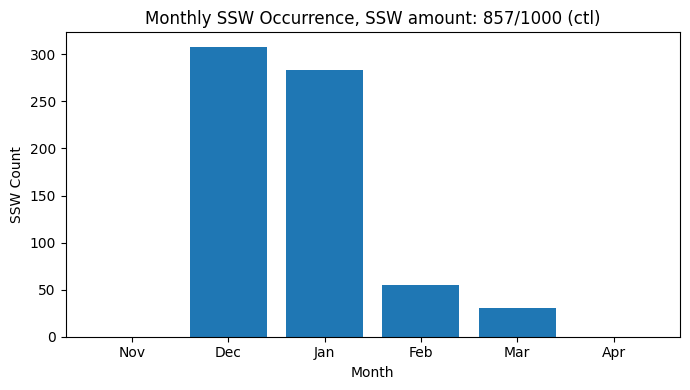

In [ ]:
import matplotlib.pyplot as plt
months = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']
plt.figure(figsize=(7,4))
plt.bar(months, barplot)
plt.xlabel('Month')
plt.ylabel('SSW Count')
plt.title('Monthly SSW Occurrence, SSW amount: ' + str(n_ssw)+'/1000' + ' ('+model+')')
plt.tight_layout()
plt.show()


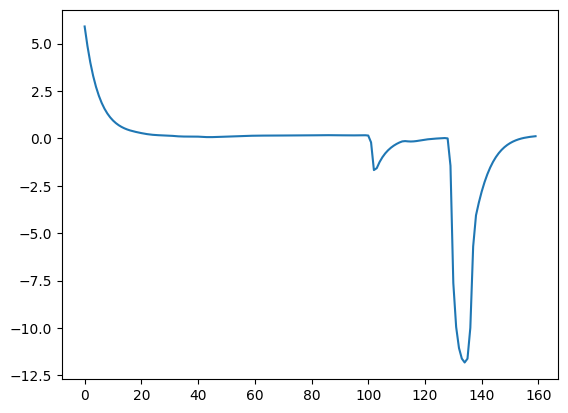

In [ ]:
plot.plot(ubar_eachyear[110,0,:])

In [ ]:
from scipy.interpolate import interp1d

# Assume the last dimension of *_eachyear is the one to interpolate (e.g., 320 -> 992)
target_len = 992

# --- FAWA ---
orig_len_fawa = fawa_eachyear.shape[2]
x_orig_fawa = np.linspace(0, 1, orig_len_fawa)
x_new = np.linspace(0, 1, target_len)

# fig, axes = plot.subplots(6, 7, figsize=(20,12), sharex=True, sharey=True)
# axes = axes.flatten()

for i in range(yr):
    interp_func = interp1d(x_orig_fawa, fawa_eachyear[110, i, :], kind='linear')
    fawa_interp = interp_func(x_new)
#     ax = axes[i]
#     ax.plot(fawa_interp, label='2023 ver.')
#     ax.plot(fawa_eachyr[64, i, :], label='ERA5')
#     ax.set_title(f'{1979+i}')
#     if i == 0:
#         ax.legend(fontsize='small')
# for j in range(yr, len(axes)):
#     axes[j].axis('off')
# fig.suptitle('FAWA at 10 hPa', fontsize=16)
# fig.tight_layout(rect=[0, 0.03, 1, 0.97])
# plot.show()

# --- UBAR ---
orig_len_ubar = ubar_eachyear.shape[2]
x_orig_ubar = np.linspace(0, 1, orig_len_ubar)
# x_new is already defined above

# fig, axes = plot.subplots(6, 7, figsize=(20,12), sharex=True, sharey=True)
# axes = axes.flatten()

for i in range(yr):
    interp_func = interp1d(x_orig_ubar, ubar_eachyear[110, i, :], kind='linear')
    ubar_interp = interp_func(x_new)
#     ax = axes[i]
#     ax.plot(ubar_interp, label='2023 ver.')
#     ax.plot(ubar_eachyr[64, i, :], label='ERA5')
#     ax.set_title(f'{1979+i}')
#     if i == 0:
#         ax.legend(fontsize='small')
# for j in range(yr, len(axes)):
#     axes[j].axis('off')
# fig.suptitle('UBAR at 10 hPa', fontsize=16)
# fig.tight_layout(rect=[0, 0.03, 1, 0.97])
# plot.show()

# --- UREF ---
orig_len_uref = uref_eachyear.shape[2]
x_orig_uref = np.linspace(0, 1, orig_len_uref)
# x_new is already defined above

# fig, axes = plot.subplots(6, 7, figsize=(20,12), sharex=True, sharey=True)
# axes = axes.flatten()

for i in range(yr):
    interp_func = interp1d(x_orig_uref, uref_eachyear[110, i, :], kind='linear')
    uref_interp = interp_func(x_new)
#     ax = axes[i]
#     ax.plot(uref_interp, label='2023 ver.')
#     ax.plot(uref_eachyr[64, i, :], label='ERA5')
#     ax.set_title(f'{1979+i}')
#     if i == 0:
#         ax.legend(fontsize='small')
# for j in range(yr, len(axes)):
#     axes[j].axis('off')
# fig.suptitle('UREF at 10 hPa', fontsize=16)
# fig.tight_layout(rect=[0, 0.03, 1, 0.97])
# plot.show()

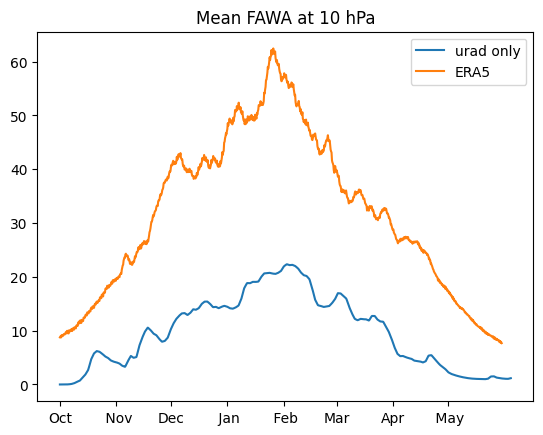

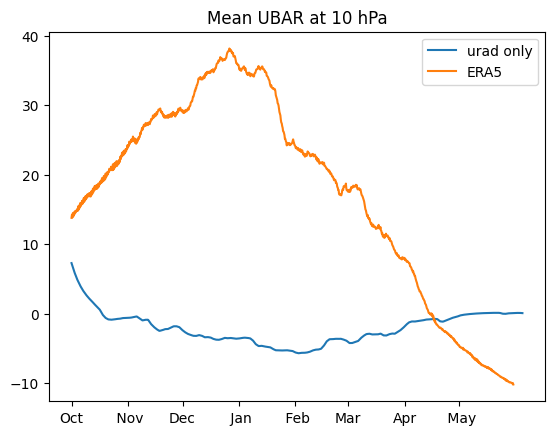

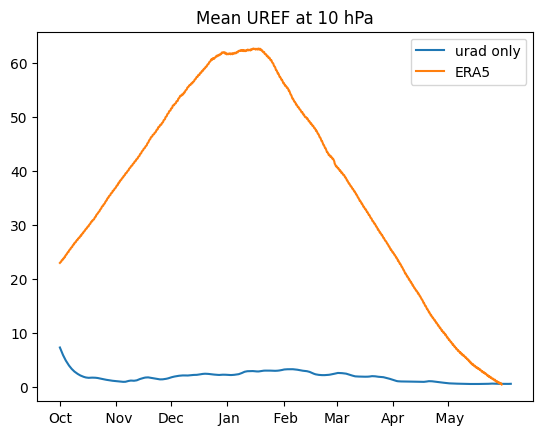

In [ ]:
# Plot the mean over axis=1 for fawa, ubar, and uref (both _eachyear and _eachyr)
# For *_eachyear, interpolate the mean as well

x = np.arange(0,992,1)/4

# FAWA
fawa_eachyear_mean = np.mean(fawa_eachyear[110, 0:40, :], axis=0)
interp_func_fawa = interp1d(x_orig_fawa, fawa_eachyear_mean, kind='linear')
fawa_eachyear_mean_interp = interp_func_fawa(x_new)
fawa_eachyr_mean = np.mean(fawa_eachyr[64, 0:40, :], axis=0)

plot.figure()
plot.plot(x,fawa_eachyear_mean_interp, label='urad only')
plot.plot(x,fawa_eachyr_mean, label='ERA5')
plot.xticks(ticks=[0,31,61,92,123,152,183,213], labels=['Oct',' Nov', 'Dec',' Jan',' Feb', 'Mar', 'Apr',' May'])
plot.legend()
plot.title('Mean FAWA at 10 hPa')
plot.show()

# UBAR
ubar_eachyear_mean = np.mean(ubar_eachyear[110, 0:40, :], axis=0)
interp_func_ubar = interp1d(x_orig_ubar, ubar_eachyear_mean, kind='linear')
ubar_eachyear_mean_interp = interp_func_ubar(x_new)
ubar_eachyr_mean = np.mean(ubar_eachyr[64, 0:40, :], axis=0)

plot.figure()
plot.plot(x,ubar_eachyear_mean_interp, label='urad only')
plot.plot(x,ubar_eachyr_mean, label='ERA5')
plot.xticks(ticks=[0,31,61,92,123,152,183,213], labels=['Oct',' Nov', 'Dec',' Jan',' Feb', 'Mar', 'Apr',' May'])
plot.legend()
plot.title('Mean UBAR at 10 hPa')
plot.show()

# UREF
uref_eachyear_mean = np.mean(uref_eachyear[110, 0:40, :], axis=0)
interp_func_uref = interp1d(x_orig_uref, uref_eachyear_mean, kind='linear')
uref_eachyear_mean_interp = interp_func_uref(x_new)
uref_eachyr_mean = np.mean(uref_eachyr[64, 0:40, :], axis=0)

plot.figure()
plot.plot(x,uref_eachyear_mean_interp, label='urad only')
plot.plot(x,uref_eachyr_mean, label='ERA5')
plot.xticks(ticks=[0,31,61,92,123,152,183,213], labels=['Oct',' Nov', 'Dec',' Jan',' Feb', 'Mar', 'Apr',' May'])
plot.legend()
plot.title('Mean UREF at 10 hPa')
plot.show()

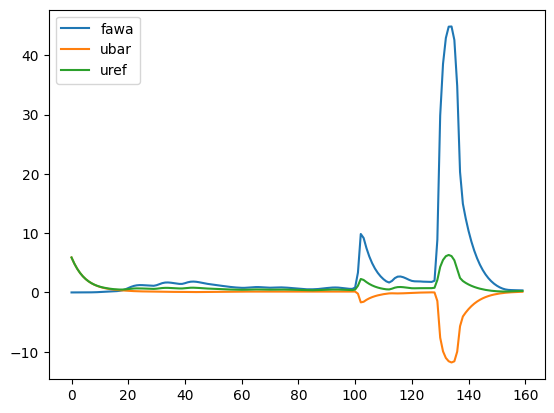

In [ ]:
plot.plot(fawa_eachyear[110,0,0:228],label='fawa')
plot.plot(ubar_eachyear[110,0,0:228],label='ubar')
plot.plot(uref_eachyear[110,0,0:228],label='uref')
plot.legend()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plot
# from scipy.interpolate import interp1d

# # 
# x = np.arange(0, 992, 1) / 4

# # 
# N_fawa = fawa_eachyear.shape[2]
# N_ubar = ubar_eachyear.shape[2]
# N_uref = uref_eachyear.shape[2]

# ci_factor = 2.576 #np.sqrt(N_fawa) #2.576  # 99% CI


# # figure
# fig, axes = plot.subplots(1, 3, figsize=(12,3), sharey=True)

# # ==== FAWA ====
# fawa_mean = np.mean(fawa_eachyear[110, 0:70, :], axis=0)
# fawa_std = np.std(fawa_eachyear[110, 0:70, :], axis=0)
# fawa_ci = ci_factor * fawa_std / np.sqrt(N_fawa)
# interp_fawa_mean = interp1d(x_orig_fawa, fawa_mean, kind='linear')
# interp_fawa_ci = interp1d(x_orig_fawa, fawa_ci, kind='linear')
# fawa_mean_interp = interp_fawa_mean(x_new)
# fawa_ci_interp = interp_fawa_ci(x_new)
# fawa_era5_mean = np.mean(fawa_eachyr[64, :, :], axis=0)

# axes[0].plot(x, fawa_mean_interp, label='1D model', color='C0')
# axes[0].fill_between(x, fawa_mean_interp - fawa_ci_interp, fawa_mean_interp + fawa_ci_interp, color='C0', alpha=0.3)
# axes[0].plot(x, fawa_era5_mean, label='ERA5 reanalysis', color='C1')
# axes[0].set_xticks([0, 31, 61, 92, 123, 152, 183, 213])
# axes[0].set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May'])
# axes[0].legend()
# axes[0].set_title('Wave activity')

# # ==== UBAR ====
# ubar_mean = np.mean(ubar_eachyear[110, 0:70, :], axis=0)
# ubar_std = np.std(ubar_eachyear[110, 0:70, :], axis=0)
# ubar_ci = ci_factor * ubar_std / np.sqrt(N_ubar)
# interp_ubar_mean = interp1d(x_orig_ubar, ubar_mean, kind='linear')
# interp_ubar_ci = interp1d(x_orig_ubar, ubar_ci, kind='linear')
# ubar_mean_interp = interp_ubar_mean(x_new)
# ubar_ci_interp = interp_ubar_ci(x_new)
# ubar_era5_mean = np.mean(ubar_eachyr[64, :, :], axis=0)

# axes[1].plot(x, ubar_mean_interp, label='1D model', color='C0')
# axes[1].fill_between(x, ubar_mean_interp - ubar_ci_interp, ubar_mean_interp + ubar_ci_interp, color='C0', alpha=0.3)
# axes[1].plot(x, ubar_era5_mean, label='ERA5 reanalysis', color='C1')
# axes[1].set_xticks([0, 31, 61, 92, 123, 152, 183, 213])
# axes[1].set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May'])
# axes[1].legend()
# axes[1].set_title('Zonal-mean zonal wind')

# # ==== UREF ====
# uref_mean = np.mean(uref_eachyear[110, 0:70, :], axis=0)
# uref_std = np.std(uref_eachyear[110, 0:70, :], axis=0)
# uref_ci = ci_factor * uref_std / np.sqrt(N_uref)
# interp_uref_mean = interp1d(x_orig_uref, uref_mean, kind='linear')
# interp_uref_ci = interp1d(x_orig_uref, uref_ci, kind='linear')
# uref_mean_interp = interp_uref_mean(x_new)
# uref_ci_interp = interp_uref_ci(x_new)
# uref_era5_mean = np.mean(uref_eachyr[64, :, :], axis=0)

# axes[2].plot(x, uref_mean_interp, label='1D model', color='C0')
# axes[2].fill_between(x, uref_mean_interp - uref_ci_interp, uref_mean_interp + uref_ci_interp, color='C0', alpha=0.3)
# axes[2].plot(x, uref_era5_mean, label='ERA5 reanalysis', color='C1')
# axes[2].set_xticks([0, 31, 61, 92, 123, 152, 183, 213])
# axes[2].set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May'])
# axes[2].legend()
# axes[2].set_title('Reference wind')

# fig.suptitle('1979 - 2021 Climatology at 10 hPa with 99% Confidence Interval', fontsize=12)

# # 
# plot.tight_layout()
# plot.show()


In [ ]:
# # Plot the distributions of fawa, ubar, and uref for both *_eachyear and *_eachyr
# # Each variable gets its own subplot, all on the same figure

# import matplotlib.pyplot as plt
# import seaborn as sns

# st_m = int(61/243*320)
# ed_m = int(151/243*320)

# st = int(61/243*992)
# ed = int(151/243*992)

# # Flatten the arrays for distribution plotting
# fawa_eachyear_flat = fawa_eachyear[110, :, :].flatten()
# fawa_eachyr_flat = fawa_eachyr[64, :, :].flatten()
# ubar_eachyear_flat = ubar_eachyear[110, :, :].flatten()
# ubar_eachyr_flat = ubar_eachyr[64, :, :].flatten()
# uref_eachyear_flat = uref_eachyear[110, :, :].flatten()
# uref_eachyr_flat = uref_eachyr[64, :, :].flatten()


# # fawa_eachyear_flat = np.mean(fawa_eachyear[220, :, st_m:ed_m],axis=0)
# # fawa_eachyr_flat = np.mean(fawa_eachyr[64, :, st:ed],axis=0)
# # ubar_eachyear_flat = np.mean(ubar_eachyear[220, :, st_m:ed_m],axis=0)
# # ubar_eachyr_flat = np.mean(ubar_eachyr[64, :, st:ed],axis=0)
# # uref_eachyear_flat = np.mean(uref_eachyear[220, :, st_m:ed_m],axis=0)
# # uref_eachyr_flat = np.mean(uref_eachyr[64, :, st:ed],axis=0)


# fig, axes = plt.subplots(3, 1, figsize=(5,7), sharex=True)

# # FAWA
# sns.kdeplot(fawa_eachyear_flat, label='FAWA urad only', fill=True, alpha=0.4, color='tab:blue', ax=axes[0])
# sns.kdeplot(fawa_eachyr_flat, label='FAWA ERA5', fill=True, alpha=0.4, color='tab:cyan', ax=axes[0])
# axes[0].legend()
# axes[0].set_title('Distribution of FAWA at 10 hPa')
# axes[0].set_ylabel('Density')
# axes[0].set_xlim(-50, 230)

# # UBAR
# sns.kdeplot(ubar_eachyear_flat, label='UBAR urad only', fill=True, alpha=0.4, color='tab:orange', ax=axes[1])
# sns.kdeplot(ubar_eachyr_flat, label='UBAR ERA5', fill=True, alpha=0.4, color='tab:olive', ax=axes[1])
# axes[1].legend()
# axes[1].set_title('Distribution of UBAR at 10 hPa')
# axes[1].set_ylabel('Density')
# axes[1].set_xlim(-50, 230)

# # UREF
# sns.kdeplot(uref_eachyear_flat, label='UREF urad only', fill=True, alpha=0.4, color='tab:green', ax=axes[2])
# sns.kdeplot(uref_eachyr_flat, label='UREF ERA5', fill=True, alpha=0.4, color='tab:purple', ax=axes[2])
# axes[2].legend()
# axes[2].set_title('Distribution of UREF at 10 hPa')
# axes[2].set_xlabel('Value')
# axes[2].set_ylabel('Density')
# axes[2].set_xlim(-50, 230)

# plt.tight_layout()
# plt.show()


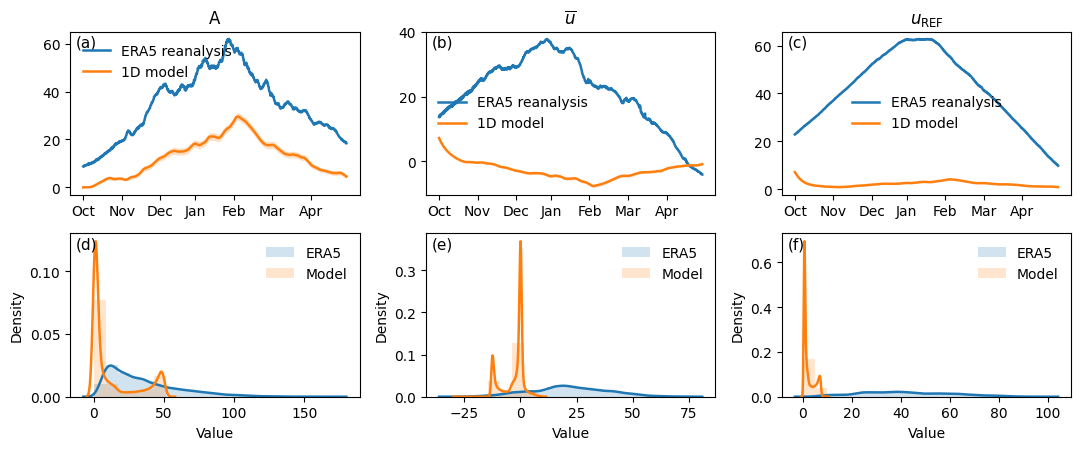

[INFO] ERA5 DJF points: 848 of 992
[INFO] FAWA model time len: 160 DJF points: 137
[INFO] UBAR model time len: 160 DJF points: 137
[INFO] UREF model time len: 160 DJF points: 137
[INFO] x_days_fawa range: 0.0 -> 211.91194968532267
[INFO] x_days_ubar  range: 0.0 -> 211.91194968532267
[INFO] x_days_uref  range: 0.0 -> 211.91194968532267


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ———  import seaborn ———
try:
    import seaborn as sns
    HAS_SNS = True
except Exception:
    HAS_SNS = False

from scipy.interpolate import interp1d
import os

# ======================
# 0) 
# ======================
# ERA56 -> 992  Oct1(0d) ~ May  247.75d
x = np.arange(0, 992, 1) / 4.0  #  Oct 1 
T_days = x.max()                # 247.75
# DJF  Oct1  0
# DEC1 = 31 + 30               # 61
# MAR1 = DEC1 + 31 + 31 + 28    # 151

DEC1 = 0               # 61
MAR1 = 31 + 30 + 31 + 31 + 28 + 31 + 30   # 151

#  x_orig_* None
x_orig_fawa = globals().get("x_orig_fawa", None)
x_orig_ubar = globals().get("x_orig_ubar", None)
x_orig_uref = globals().get("x_orig_uref", None)

# ==========  + (yrs,time) DJF  ==========
def _auto_time_coord(n_time, x_orig_like):
    """
     time Oct1  n_time
    
    1) · ~ 0..~248 -> 
    2)  0..n_time-1          ->  0..T_days
    3)  0..1                ->  T_days
    min..max -> 0..T_days
    """
    if x_orig_like is None:
        # 
        idx = np.linspace(0, 1, n_time)
        return idx * T_days

    x_arr = np.asarray(x_orig_like, dtype=float)
    if x_arr.size != n_time:
        # 
        idx = np.linspace(0, 1, n_time)
        return idx * T_days

    # 
    x_min, x_max = float(np.nanmin(x_arr)), float(np.nanmax(x_arr))
    span = x_max - x_min + 1e-12

    # 1)  0..~248
    if x_max >= 200 and x_max <= 400 and x_min > -5:
        #  0..~248 
        #  0  [0, x_max-x_min]
        x_days = x_arr - x_min
        #  ERA5 
        x_days = (x_days / (x_days.max() + 1e-12)) * T_days
        return x_days

    # 2)  0..1
    if x_min >= -1e-6 and x_max <= 1.0 + 1e-6:
        return (x_arr - x_min) / span * T_days

    # 3)  0..n_time-1
    if x_min >= -1e-6 and abs(x_max - (n_time - 1)) < 1e-6:
        return (x_arr - x_min) / span * T_days

    #  0..T_days
    return (x_arr - x_min) / span * T_days


def _djf_mask_from_days(x_days):
    """Oct1  DJF(Dec1~Mar1) """
    return (x_days >= DEC1) & (x_days < MAR1)


def _subseries_DJF(year_time_array, x_orig_like=None):
    """
    year_time_array  (years, time)
         x_orig_like        time /
    
      arr_DJF: (years, time_djf)
      x_sub :  (time_djf,) —— Oct1 /
    """
    n_time = year_time_array.shape[1]
    x_days = _auto_time_coord(n_time, x_orig_like)
    mask = _djf_mask_from_days(x_days)

    #  FalseDEC1/T_days .. MAR1/T_days
    if not np.any(mask):
        frac = np.linspace(0, 1, n_time)
        lo, hi = DEC1 / T_days, MAR1 / T_days
        mask = (frac >= lo) & (frac < hi)

    arr_DJF = year_time_array[:, mask]
    x_sub = x_days[mask]
    return arr_DJF, x_sub


# ========== ERA5  DJF  ==========
mask_era = _djf_mask_from_days(x)
x_win = x[mask_era]               # DJF  ERA5 Oct1 
x_new = x_win - DEC1              #  =>  Dec1 0~90

# ======================
#  CI
# ======================
# (level, years, time)
N_fawa = fawa_eachyear.shape[1]
N_ubar = ubar_eachyear.shape[1]
N_uref = uref_eachyear.shape[1]
ci_factor = 2.576  # 99% CI

# ======================
# 1)  2×3 
# ======================
fig, axes = plt.subplots(2, 3, figsize=(11, 4.8))
top_axes = axes[0]   # +CI
bot_axes = axes[1]   #  KDE/

# ----------------------
# +CI ERA5 Model
# ----------------------
def plot_clim_with_ci(ax, mean_raw, std_raw, n_years, x_days_sub, era5_mean_sub, title):
    """
    mean_raw, std_raw:  DJF  (time_subset,)/
    x_days_sub       : Oct1 
    era5_mean_sub    : ERA5 DJF  (time_subset,)
    """
    if len(x_days_sub) != len(mean_raw):
        raise ValueError("x_days_sub  mean_raw ")

    ci = ci_factor * std_raw / np.sqrt(n_years)

    #  model  DJF  (DEC1 + x_new)  ERA5  DJF 
    f_mean = interp1d(x_days_sub, mean_raw, kind='linear', fill_value="extrapolate", assume_sorted=False)
    f_ci   = interp1d(x_days_sub, ci,       kind='linear', fill_value="extrapolate", assume_sorted=False)
    mean_i = f_mean(DEC1 + x_new)
    ci_i   = f_ci  (DEC1 + x_new)

    # ERA5 -> Model
    era5_line,  = ax.plot(x_new, era5_mean_sub, label='ERA5 reanalysis',  lw=1.8)
    model_line, = ax.plot(x_new, mean_i,        label='1D model',         lw=1.8)
    ax.fill_between(x_new, mean_i - ci_i, mean_i + ci_i, color='C1', alpha=0.25, linewidth=0)

    # DJF  Dec1 
    ax.set_xticks([0, 31, 62, 90, 121, 152, 183])  # Dec1, Jan1, Feb1, Mar1
    # ax.set_xticklabels(['Dec', 'Jan', 'Feb', 'Mar 1'])
    ax.set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr'])
    ax.set_title(title)
    ax.legend([era5_line, model_line], ['ERA5 reanalysis', '1D model'], frameon=False)

# ======================
# 2) FAWA / UBAR / UREF  + 99% CI DJF 
# ======================
# —— FAWA ——
fawa_model = fawa_eachyear[110, :, :]         # (years, time_model)
fawa_model_DJF, x_days_fawa = _subseries_DJF(fawa_model, x_orig_fawa)
fawa_mean = np.mean(fawa_model_DJF, axis=0)
fawa_std  = np.std (fawa_model_DJF, axis=0)

fawa_era5 = fawa_eachyr[64, :, :]             # (years, time_era=992)
fawa_era5_DJF = fawa_era5[:, mask_era]
fawa_era5_mean = np.mean(fawa_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[0],
    mean_raw=fawa_mean,
    std_raw=fawa_std,
    n_years=N_fawa,
    x_days_sub=x_days_fawa,
    era5_mean_sub=fawa_era5_mean,
    title='A'
)

# —— UBAR ——
ubar_model = ubar_eachyear[110, :, :]

#  -50 
ubar_model = np.where(ubar_model < -30, np.nan, ubar_model)

ubar_model_DJF, x_days_ubar = _subseries_DJF(ubar_model, x_orig_ubar)
ubar_mean = np.nanmean(ubar_model_DJF, axis=0)
ubar_std  = np.nanstd (ubar_model_DJF, axis=0)

ubar_era5 = ubar_eachyr[64, :, :]
ubar_era5 = np.where(ubar_era5 < -30, np.nan, ubar_era5)
ubar_era5_DJF = ubar_era5[:, mask_era]
ubar_era5_mean = np.nanmean(ubar_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[1],
    mean_raw=ubar_mean,
    std_raw=ubar_std,
    n_years=N_ubar,
    x_days_sub=x_days_ubar,
    era5_mean_sub=ubar_era5_mean,
    title=r'$\overline{u}$'
)

# —— UREF ——
uref_model = uref_eachyear[110, :, :]
uref_model = np.where(uref_model < 0, np.nan, uref_model)
uref_model_DJF, x_days_uref = _subseries_DJF(uref_model, x_orig_uref)
uref_mean = np.nanmean(uref_model_DJF, axis=0)
uref_std  = np.nanstd(uref_model_DJF, axis=0)

uref_era5 = uref_eachyr[64, :, :]
uref_era5 = np.where(uref_era5 < 0, np.nan, uref_era5)
uref_era5_DJF = uref_era5[:, mask_era]
uref_era5_mean = np.nanmean(uref_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[2],
    mean_raw=uref_mean,
    std_raw=uref_std,
    n_years=N_uref,
    x_days_sub=x_days_uref,
    era5_mean_sub=uref_era5_mean,
    title=r'$u_{\mathrm{REF}}$'
)

# ======================
# 3)  DJF  ERA5 Model
# ======================
def kde_or_hist(ax, era5_arr, model_arr, title='', xlabel=False, ylabel=False,
                bins=20, alpha_hist=0.2, lw_kde=1.8):
    """ histogram  KDE  bins"""
    era5_arr  = np.asarray(era5_arr).ravel()
    model_arr = np.asarray(model_arr).ravel()

    #  matplotlib 
    cycle_colors = plt.rcParams.get('axes.prop_cycle').by_key().get('color', ['C0','C1'])
    c_era5  = cycle_colors[0]
    c_model = cycle_colors[1]

    #  bins
    data_min = np.nanmin([np.nanmin(era5_arr), np.nanmin(model_arr)])
    data_max = np.nanmax([np.nanmax(era5_arr), np.nanmax(model_arr)])
    bin_edges = np.linspace(data_min, data_max, bins + 1)

    # density=True  KDE 
    ax.hist(era5_arr,  bins=bin_edges, density=True, alpha=alpha_hist,
            color=c_era5,  label='ERA5')
    ax.hist(model_arr, bins=bin_edges, density=True, alpha=alpha_hist,
            color=c_model, label='Model')

    # KDEKDE  legend
    if HAS_SNS:
        sns.kdeplot(era5_arr,  ax=ax, lw=lw_kde, fill=False, color=c_era5,  label='_nolegend_')
        sns.kdeplot(model_arr, ax=ax, lw=lw_kde, fill=False, color=c_model, label='_nolegend_')

    ax.set_title(title)
    if ylabel:
        ax.set_ylabel('Density')
    if xlabel:
        ax.set_xlabel('Value')
    ax.legend(frameon=False)



fawa_model_flat = fawa_model_DJF.ravel()
fawa_era5_flat  = fawa_era5_DJF.ravel()
ubar_model_flat = ubar_model_DJF.ravel()
ubar_era5_flat  = ubar_era5_DJF.ravel()
uref_model_flat = uref_model_DJF.ravel()
uref_era5_flat  = uref_era5_DJF.ravel()

kde_or_hist(bot_axes[0], fawa_era5_flat,  fawa_model_flat, title='', xlabel=True, ylabel=True)
kde_or_hist(bot_axes[1], ubar_era5_flat,  ubar_model_flat, title='', xlabel=True, ylabel=False)
kde_or_hist(bot_axes[2], uref_era5_flat,  uref_model_flat, title='', xlabel=True, ylabel=False)

# 
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for ax, lab in zip(axes.ravel(), labels):
    ax.text(0.02, 0.98, lab, transform=ax.transAxes,
            ha='left', va='top', fontsize=11)

# ======================
# 4)  & 
# ======================
# fig.suptitle('DJF (Dec–Feb) Climatology at 10 hPa (Top, with 99% CI) and Distributions (Bottom)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])

os.makedirs('output', exist_ok=True)
plt.savefig('output/validation_DJF.png', dpi=600, bbox_inches='tight')
plt.show()

# —— ——
print("[INFO] ERA5 DJF points:", mask_era.sum(), "of", x.size)
print("[INFO] FAWA model time len:", fawa_model.shape[1], "DJF points:", fawa_model_DJF.shape[1])
print("[INFO] UBAR model time len:", ubar_model.shape[1], "DJF points:", ubar_model_DJF.shape[1])
print("[INFO] UREF model time len:", uref_model.shape[1], "DJF points:", uref_model_DJF.shape[1])
print("[INFO] x_days_fawa range:", float(x_days_fawa.min()), "->", float(x_days_fawa.max()))
print("[INFO] x_days_ubar  range:", float(x_days_ubar.min()),  "->", float(x_days_ubar.max()))
print("[INFO] x_days_uref  range:", float(x_days_uref.min()),  "->", float(x_days_uref.max()))


ctl: ubar shape = (1000, 160, 501), fawa shape = (1000, 160, 501), nt_per_year = 160
linear: ubar shape = (1000, 160, 501), fawa shape = (1000, 160, 501), nt_per_year = 160
exp: ubar shape = (1000, 160, 501), fawa shape = (1000, 160, 501), nt_per_year = 160


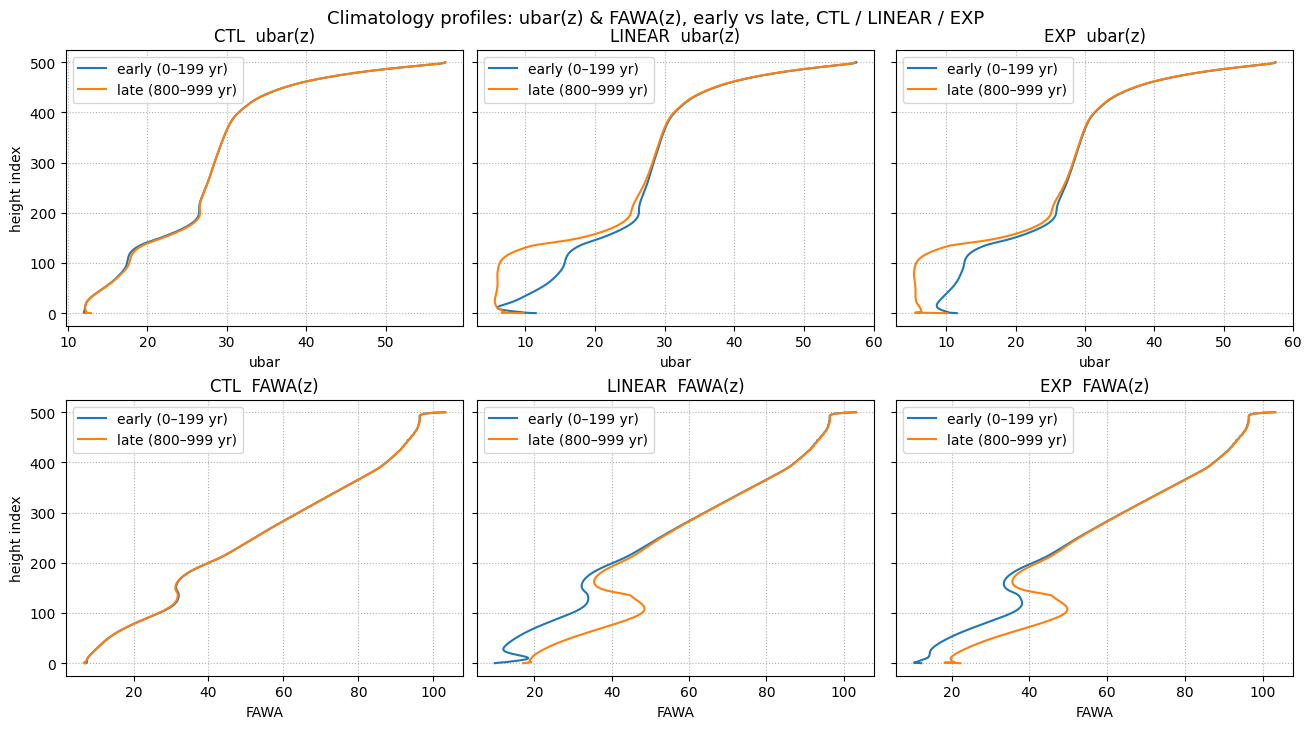

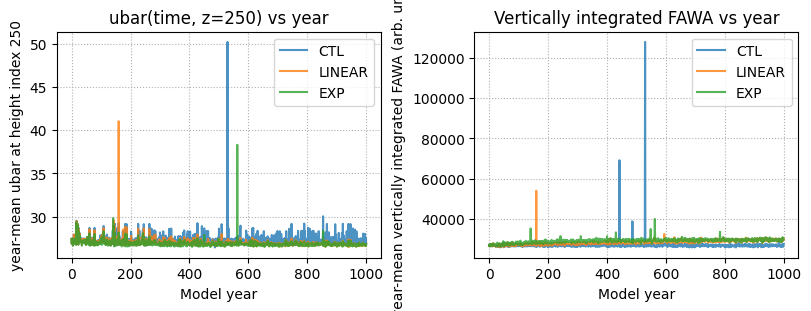

In [ ]:
import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt

# =========================
# 0. 
# =========================


nyear = 1000        # 1000 
base = "/scratch/smliu01/1d_model/climatechange/forcing"

paths = {
    "ctl": {
        "u": f"{base}/ctl/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
        "a": f"{base}/ctl/aout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
    },
    "linear": {
        "u": f"{base}/linear/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
        "a": f"{base}/linear/aout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
    },
    "exp": {
        "u": f"{base}/exp/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
        "a": f"{base}/exp/aout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
    },
}

# early / late 
early_slice = slice(0, 200)       # 0–199 
late_slice  = slice(800, 1000)    # 800–999 

#  index0–500 
iz_level = 250    # 


# =========================
# 1.  ubar / fawa  reshape
# =========================

def load_ubar_fawa(path_u, path_a,
                   varname_u="ubar", varname_a="fawa",
                   nyear=1000):
    """
    path_u: uout  ubar(height, time)
    path_a: aout  fawa(height, time)

    :
      u_yth: (year, time_in_year, height)
      a_yth: (year, time_in_year, height)
      nt_per_year:  time 
      nz: 
    """
    # ----  ubar ----
    with Dataset(path_u) as nc_u:
        u_raw = np.array(nc_u[varname_u][:])   # (height, time)
        #  height  shape
        nheight, ntime = u_raw.shape
        #  (time, height)
        u_th = u_raw.T                          # (time, height)

    # ----  fawa ----
    with Dataset(path_a) as nc_a:
        a_raw = np.array(nc_a[varname_a][:])   # (height, time)
        a_th = a_raw.T                         # (time, height)

    # ---- reshape ----
    nt_total, nz = u_th.shape
    assert nt_total == a_th.shape[0] and nz == a_th.shape[1], "ubar/fawa "

    nt_per_year = nt_total // nyear
    assert nt_per_year * nyear == nt_total, "time  nyear "

    u_yth = u_th.reshape(nyear, nt_per_year, nz)  # (year, time, height)
    a_yth = a_th.reshape(nyear, nt_per_year, nz)

    return u_yth, a_yth, nt_per_year, nz


data = {}
nt_per_year_all = None

for tag in ["ctl", "linear", "exp"]:
    u_yth, a_yth, nt_per_year, nz = load_ubar_fawa(
        paths[tag]["u"], paths[tag]["a"],
        varname_u="ubar", varname_a="fawa",
        nyear=nyear
    )
    data[tag] = {
        "ubar": u_yth,    # (year, time, height)
        "fawa": a_yth,    # (year, time, height)
        "nz": nz
    }
    print(f"{tag}: ubar shape = {u_yth.shape}, fawa shape = {a_yth.shape}, nt_per_year = {nt_per_year}")

    if nt_per_year_all is None:
        nt_per_year_all = nt_per_year
    else:
        assert nt_per_year_all == nt_per_year, " nt_per_year "

#  index 0..nz-1
z_index = np.arange(nz)

#  iz_level 
if iz_level < 0 or iz_level >= nz:
    raise ValueError(f"iz_level={iz_level}  [0, {nz-1}] ")


# =========================
# 2. 
# =========================

def clim_profile(field_yth, year_slice):
    """
    field_yth: (year, time, height)
    year_slice: slice  slice(0,200)  slice(800,1000)
    :  climatology profile (height,)
    """
    return field_yth[year_slice, :, :].mean(axis=(0, 1))

def level_mean_time_series(field_yth, iz, year_slice=None):
    """
     iz  time series
    field_yth: (year, time, height)
    iz: int,  index
    year_slice:  slice
    : (year,)  time series
    """
    if year_slice is None:
        sub = field_yth[:, :, iz]   # (year, time)
    else:
        sub = field_yth[year_slice, :, iz]
    return sub.mean(axis=1)

def vert_int_time_series(field_yth, year_slice=None):
    """
     time  height 
     (year,) time series
    """
    if year_slice is None:
        sub = field_yth[:, :, :]   # (year, time, height)
    else:
        sub = field_yth[year_slice, :, :]
    #  -> (year, height) height 
    return sub.mean(axis=1).sum(axis=1)


# =========================
# 3. ubar(z) & FAWA(z)early vs late
# =========================

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True, constrained_layout=True)

for j, tag in enumerate(["ctl", "linear", "exp"]):
    u_yth = data[tag]["ubar"]
    a_yth = data[tag]["fawa"]

    u_early = clim_profile(u_yth, early_slice)    # (height,)
    u_late  = clim_profile(u_yth, late_slice)
    a_early = clim_profile(a_yth, early_slice)
    a_late  = clim_profile(a_yth, late_slice)

    # ubar(z)
    ax = axes[0, j]
    ax.plot(u_early, z_index, label="early (0–199 yr)")
    ax.plot(u_late,  z_index, label="late (800–999 yr)")
    ax.set_title(f"{tag.upper()}  ubar(z)")
    ax.set_xlabel("ubar")
    if j == 0:
        ax.set_ylabel("height index")
    ax.invert_yaxis()
    ax.grid(True, linestyle=":")
    ax.legend()

    # FAWA(z)
    ax = axes[1, j]
    ax.plot(a_early, z_index, label="early (0–199 yr)")
    ax.plot(a_late,  z_index, label="late (800–999 yr)")
    ax.set_title(f"{tag.upper()}  FAWA(z)")
    ax.set_xlabel("FAWA")
    if j == 0:
        ax.set_ylabel("height index")
    ax.invert_yaxis()
    ax.grid(True, linestyle=":")
    ax.legend()

plt.suptitle("Climatology profiles: ubar(z) & FAWA(z), early vs late, CTL / LINEAR / EXP",
             y=1.02, fontsize=13)
# plt.savefig("ubar_fawa_profiles_early_late_ctl_linear_exp.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# 4.  ubar   FAWA 
# =========================

years = np.arange(nyear)

fig, axes = plt.subplots(1, 2, figsize=(8,3), constrained_layout=True)

# (a) ubar(iz_level)  vs year
ax = axes[0]
for tag, color in zip(["ctl", "linear", "exp"], ["C0", "C1", "C2"]):
    u_yth = data[tag]["ubar"]
    u_level_ts = level_mean_time_series(u_yth, iz_level)
    ax.plot(years, u_level_ts, label=tag.upper(), alpha=0.8)
ax.set_xlabel("Model year")
ax.set_ylabel(f"year-mean ubar at height index {iz_level}")
ax.set_title(f"ubar(time, z={iz_level}) vs year")
ax.grid(True, linestyle=":")
ax.legend()

# (b) FAWA  sum_zvs year
ax = axes[1]
for tag, color in zip(["ctl", "linear", "exp"], ["C0", "C1", "C2"]):
    a_yth = data[tag]["fawa"]
    fawa_int_ts = vert_int_time_series(a_yth)
    ax.plot(years, fawa_int_ts, label=tag.upper(), alpha=0.8)
ax.set_xlabel("Model year")
ax.set_ylabel("year-mean vertically integrated FAWA (arb. units)")
ax.set_title("Vertically integrated FAWA vs year")
ax.grid(True, linestyle=":")
ax.legend()

# plt.savetxt("years.txt", years)  #  time series 
# plt.savefig("ubar_level_fawaInt_vs_year_ctl_linear_exp.png", dpi=300, bbox_inches="tight")
plt.show()


=== Control ===
  total events = 679
  mean event frequency = 0.679 yr^-1
  fraction of winters with >=1 SSW = 0.526
=== Top ===
  total events = 533
  mean event frequency = 0.533 yr^-1
  fraction of winters with >=1 SSW = 0.425
=== Top + Bottom ===
  total events = 640
  mean event frequency = 0.640 yr^-1
  fraction of winters with >=1 SSW = 0.500
=== Top - Bottom ===
  total events = 414
  mean event frequency = 0.414 yr^-1
  fraction of winters with >=1 SSW = 0.339

Running-mean diagnostic:
  Control       : annual mean=0.679, running-mean average=0.678, range=0.340 to 0.980
  Top           : annual mean=0.533, running-mean average=0.532, range=0.206 to 0.940
  Top + Bottom  : annual mean=0.640, running-mean average=0.639, range=0.340 to 0.960
  Top - Bottom  : annual mean=0.414, running-mean average=0.413, range=0.120 to 0.900

Layer-mean delta uRAD:
  upper layer = 32.16-49.92 km, nlev=90
  lower/middle layer = 10.00-31.96 km, nlev=111

Delta uRAD ranges:
  Top - Control: +0.000 

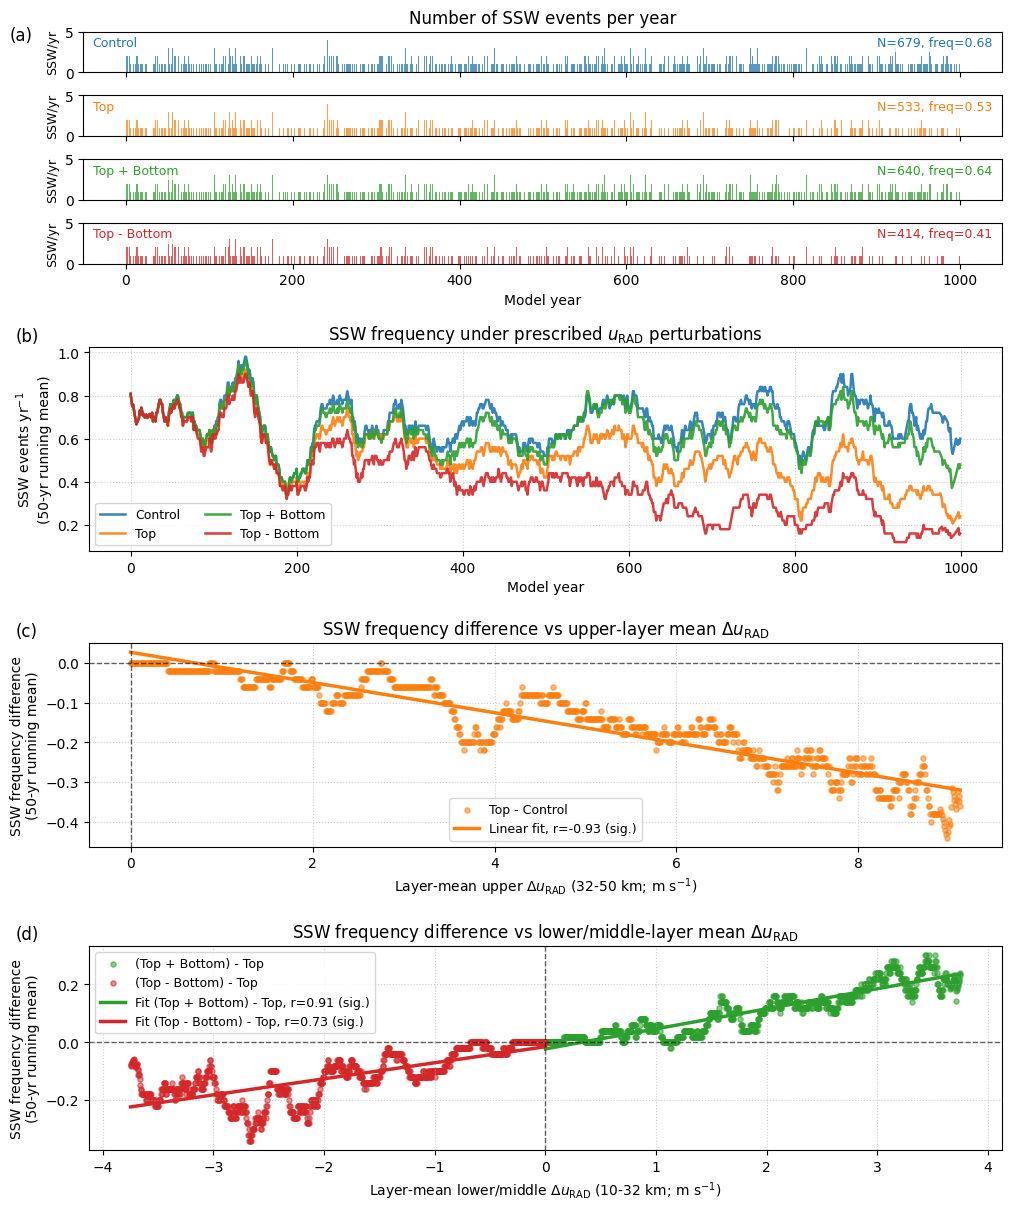

In [1]:
# import numpy as np
# from netCDF4 import Dataset
# import matplotlib.pyplot as plt

# # =====================================================
# # 0.  1D  ubar -> ERA5  ubp,date
# #     years 
# # =====================================================

# def model_ubar_to_era5_like_inputs(
#     ubar_model,          # shape = (nz, years*steps_per_year)
#     level_index,         #  SSW  110
#     years,               #  1000
#     steps_per_year,      #  160
#     start_year=1979      # 
# ):
#     """
#     
#       ubp:  shape = (years, 992)  6-hourly Oct–May 
#       date: list[list[str]]'YYYY/MM/DD/HH' ubp 
#     """
#     nz, nt = ubar_model.shape
#     assert nt == years * steps_per_year, " years*steps_per_year "

#     # 1)  reshape  (years, steps_per_year)
#     u = np.array(ubar_model[level_index, :], dtype=float).reshape(years, steps_per_year)

#     # 2)  6-hourly  992 
#     tgt_len = 992
#     src_x = np.arange(steps_per_year, dtype=float)
#     tgt_x = np.linspace(0, steps_per_year - 1, tgt_len)

#     ubp = np.empty((years, tgt_len), dtype=float)
#     for y in range(years):
#         ubp[y] = np.interp(tgt_x, src_x, u[y])

#     # 3)  date  'YYYY/MM/DD/HH'
#     time4 = ['00', '06', '12', '18']
#     months = ['10', '11', '12', '01', '02', '03', '04', '05']
#     days31 = [f"{d:02d}" for d in range(1, 32)]  #  31 
#     date = [[None]*tgt_len for _ in range(years)]

#     for y in range(years):
#         k = 0
#         for mi, mm in enumerate(months):
#             year_label = (start_year + y) if mi < 3 else (start_year + y + 1)
#             for dd in days31:
#                 for hh in time4:
#                     date[y][k] = f"{year_label}/{mm}/{dd}/{hh}"
#                     k += 1
#         assert k == tgt_len

#     return ubp, date

# # =====================================================
# # 1.  & 
# # =====================================================

# nyear = 1000
# steps_per_year = 160           #  1D 
# level_index = 110              #  SSW 
# start_year = 1979

# base = "/scratch/smliu01/1d_model/climatechange/forcing"

# paths_u = {
#     "ctl":    f"{base}/ctl/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
#     "linear": f"{base}/linear/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
#     "satur":    f"{base}/exp/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc",
# }

# #  count_ssw_events_from_ubar_legacy 
# dmax_for_ssw = 992             #  6-hourly 
# DMAX_REF_FOR_DAYS = 992.0      # dmax_ref ERA5 
# WIN_YEARS = 50                 # 30 



# # =====================================================
# # Graybox-style SSW detection
# # =====================================================

# def count_ssw_events_from_u10(
#     u_all_flat,
#     n_per_year,
#     years,
#     dmax_ref=992,
#     min_gap_days=10,
#     min_gap_onset_days=20,
#     min_duration_days=2,
#     use_djf_only=False,
#     return_debug=False,
#     date_2d=None,
#     enforce_march10_cutoff=True,
#     exclude_onset_indices=None,
# ):
#     """
#     Graybox-style SSW detection.

#     
#       u_all_flat : flatten  10 hPa ubar
#       n_per_year : graybox/ERA5-like  992
#       years : 
#       date_2d : shape = (years, n_per_year),  'YYYY/MM/DD/HH'

#     
#       1. u10 < 0 
#       2.  >= min_duration_days
#       3.  min_gap_days
#       4. onset  min_gap_onset_days
#       5.  March 10 cutoff
#     """
#     u_all_flat = np.asarray(u_all_flat, dtype=float)

#     assert u_all_flat.size == years * n_per_year, (
#         f"u_all_flat ={u_all_flat.size}, "
#         f" years*n_per_year={years*n_per_year}"
#     )

#     u_2d = u_all_flat.reshape(years, n_per_year)

#     scale = n_per_year / float(dmax_ref)
#     steps_per_day = 4.0 * scale

#     min_gap_steps = max(1, int(round(min_gap_days * steps_per_day)))
#     min_gap_onset_steps = max(1, int(round(min_gap_onset_days * steps_per_day)))
#     min_duration_steps = max(1, int(round(min_duration_days * steps_per_day)))

#     djf_start = None
#     djf_end = None

#     if use_djf_only:
#         djf_start_frac = 2.0 / 7.0
#         djf_end_frac = 5.0 / 7.0

#         djf_start = int(round(djf_start_frac * n_per_year))
#         djf_end = int(round(djf_end_frac * n_per_year))

#         djf_mask = np.zeros_like(u_2d, dtype=bool)
#         djf_mask[:, djf_start:djf_end] = True

#         neg_2d = (u_2d < 0.0) & djf_mask
#         neg_flat = neg_2d.ravel()
#     else:
#         neg_flat = (u_2d < 0.0).ravel()

#     T = neg_flat.size

#     if T == 0:
#         debug = dict(
#             steps_per_day=steps_per_day,
#             min_gap_steps=min_gap_steps,
#             min_gap_onset_steps=min_gap_onset_steps,
#             min_duration_steps=min_duration_steps,
#             djf_start=djf_start,
#             djf_end=djf_end,
#             raw_events=[],
#             filtered_events=[],
#             final_events=[],
#         )
#         return (0, [], debug) if return_debug else (0, [])

#     # -----------------------------
#     # 1.  u < 0 
#     # -----------------------------
#     onsets = []
#     ends = []

#     if neg_flat[0]:
#         onsets.append(0)

#     for t in range(1, T):
#         if neg_flat[t] and not neg_flat[t - 1]:
#             onsets.append(t)

#         if (not neg_flat[t]) and neg_flat[t - 1]:
#             ends.append(t - 1)

#     if neg_flat[-1]:
#         ends.append(T - 1)

#     m = min(len(onsets), len(ends))
#     onsets = onsets[:m]
#     ends = ends[:m]

#     raw_events = [(s, e) for s, e in zip(onsets, ends) if e > s]

#     # -----------------------------
#     # 2.  + 
#     # -----------------------------
#     filtered = []

#     for s, e in raw_events:
#         duration = e - s + 1

#         if duration < min_duration_steps:
#             continue

#         # graybox 
#         if ((e + 1) % n_per_year) == 0:
#             continue

#         filtered.append((s, e))

#     # -----------------------------
#     # 3. 
#     # -----------------------------
#     final_events = []

#     for s, e in filtered:
#         if not final_events:
#             final_events.append((s, e))
#             continue

#         s_prev, e_prev = final_events[-1]

#         ok_gap_prev_end = (s - e_prev) >= min_gap_steps
#         ok_gap_prev_onset = (s - s_prev) >= min_gap_onset_steps

#         ok_gap_prev2_end = True
#         if len(final_events) >= 2:
#             s_prev2, e_prev2 = final_events[-2]
#             ok_gap_prev2_end = (s - e_prev2) >= min_gap_steps

#         if ok_gap_prev_end and ok_gap_prev2_end and ok_gap_prev_onset:
#             final_events.append((s, e))

#     # -----------------------------
#     # 4.  1-based global onset index 
#     # -----------------------------
#     if exclude_onset_indices is not None and len(exclude_onset_indices) > 0:
#         exclude_set_1based = set(int(x) for x in exclude_onset_indices)

#         kept = []
#         for s, e in final_events:
#             t1 = s + 1
#             if t1 in exclude_set_1based:
#                 continue
#             kept.append((s, e))

#         final_events = kept

#     # -----------------------------
#     # 5. March 10 cutoff
#     # -----------------------------
#     if enforce_march10_cutoff and (date_2d is not None):
#         date_2d = np.asarray(date_2d)

#         assert date_2d.shape == (years, n_per_year), (
#             f"date_2d  ({years}, {n_per_year})"
#             f" {date_2d.shape}"
#         )

#         kept = []

#         for s, e in final_events:
#             iy = s // n_per_year
#             jy = s % n_per_year

#             dstr = str(date_2d[iy, jy])

#             # date format: 'YYYY/MM/DD/HH'
#             mm = int(dstr[5:7])
#             dd = int(dstr[8:10])

#             # graybox cutoff 
#             if (mm == 3 and dd > 10) or (mm == 4) or (mm == 5) or (mm == 11):
#                 continue

#             kept.append((s, e))

#         final_events = kept

#     n_ssw = len(final_events)

#     debug = dict(
#         steps_per_day=steps_per_day,
#         min_gap_steps=min_gap_steps,
#         min_gap_onset_steps=min_gap_onset_steps,
#         min_duration_steps=min_duration_steps,
#         djf_start=djf_start,
#         djf_end=djf_end,
#         raw_events=raw_events,
#         filtered_events=filtered,
#         final_events=final_events,
#     )

#     return (n_ssw, final_events, debug) if return_debug else (n_ssw, final_events)

# # =====================================================
# # 2.  nc  flags & events
# # =====================================================

# def compute_ssw_flags_from_nc(
#     path_u,
#     level_index,
#     years,
#     steps_per_year,
#     start_year=1979,
# ):
#     """
#     path_u: uout nc 

#     
#       flags:  shape = (years,),  SSW, 0/1
#       events: [(s, e), ...], flatten  0-based index dmax=992
#       debug: graybox-style SSW  debug dict
#     """
#     # ----  ubar(height, time) ----
#     with Dataset(path_u) as nc:
#         ubar_model = np.array(nc["ubar"][:])

#     nz, nt = ubar_model.shape

#     assert nt == years * steps_per_year, (
#         f"time  years*steps_per_year: "
#         f"nt={nt}, years*steps_per_year={years * steps_per_year}"
#     )

#     # ----  ERA5-like / graybox  992  ----
#     ubp_model, date_model = model_ubar_to_era5_like_inputs(
#         ubar_model,
#         level_index=level_index,
#         years=years,
#         steps_per_year=steps_per_year,
#         start_year=start_year,
#     )

#     # ubp_model: shape = (years, 992)
#     dmax = ubp_model.shape[1]

#     # ---- graybox-style SSW  ----
#     n_ssw, events, debug = count_ssw_events_from_u10(
#         u_all_flat=ubp_model.reshape(-1),
#         n_per_year=dmax,
#         years=years,
#         dmax_ref=992,
#         min_gap_days=10,
#         min_gap_onset_days=20,
#         min_duration_days=2,
#         use_djf_only=False,
#         return_debug=True,
#         date_2d=date_model,
#         enforce_march10_cutoff=True,
#         exclude_onset_indices=None,
#     )

#     # ----  0/1  ----
#     flags = np.zeros(years, dtype=int)

#     for s, e in events:
#         iy = s // dmax

#         if 0 <= iy < years:
#             flags[iy] = 1

#     return flags, events, debug

# # =====================================================
# # 3.  ctl / linear / exp  run  SSW
# # =====================================================

# ssw_flags = {}
# ssw_events = {}
# ssw_debug  = {}

# for tag in ["ctl", "linear", "satur"]:
#     print(f"=== {tag.upper()} ===")
#     flags, events, debug = compute_ssw_flags_from_nc(
#         paths_u[tag],
#         level_index=level_index,
#         years=nyear,
#         steps_per_year=steps_per_year,
#         start_year=start_year
#     )
#     ssw_flags[tag]  = flags
#     ssw_events[tag] = events
#     ssw_debug[tag]  = debug

#     print(f"  total events = {len(events)}, mean freq ~ {flags.mean():.3f}")

# years_arr = np.arange(nyear)

# # =====================================================
# # 4. 30  SSW 
# # =====================================================

# # def running_mean(x, win):
# #     return np.convolve(x, np.ones(win), mode="same") / float(win)

# def running_mean_edgeaware(x, win):
#     x = np.asarray(x, float)
#     n = x.size
#     half = win // 2
#     out = np.empty(n)
#     for i in range(n):
#         i0 = max(0, i-half)
#         i1 = min(n, i+half+1)
#         out[i] = x[i0:i1].mean()
#     return out

# # ssw_freq = {tag: running_mean_edgeaware(ssw_flags[tag], WIN_YEARS)
# #             for tag in ["ctl", "linear", "satur"]}


# # =====================================================
# # 5.  forcing amplitude 
# # =====================================================

# amp = {}
# amp["ctl"] = np.ones_like(years_arr, dtype=float)

# # linear_r10:  100  +10%
# r_linear = 0.10
# amp["linear"] = 1.0 + r_linear * years_arr / 100.0

# # exp_A1.0_tau250: F = F0 [1 + A (1 - exp(-t/τ))]
# A_max = 1.0
# tau   = 250.0
# amp["satur"] = 1.0 + A_max * (1.0 - np.exp(-years_arr / tau))

# # =====================================================
# # 6. Fig. a/b/c
# # =====================================================

# from scipy.stats import pearsonr

# # ----------  SSW event  ----------
# def counts_per_year_from_events(events, years, dmax):
#     counts = np.zeros(years, dtype=int)
#     for (s, e) in events:
#         iy = s // dmax
#         if 0 <= iy < years:
#             counts[iy] += 1
#     return counts

# counts = {}
# counts_total = {}

# for tag in ["ctl", "linear", "satur"]:
#     counts[tag] = counts_per_year_from_events(
#         ssw_events[tag], years=nyear, dmax=dmax_for_ssw
#     )
#     counts_total[tag] = np.sum(counts[tag])

# # ---------- 50  counts 1 ----------
# ssw_freq = {
#     tag: running_mean_edgeaware(counts[tag], WIN_YEARS)
#     for tag in ["ctl", "linear", "satur"]
# }

# # ----------  ----------
# fig = plt.figure(figsize=(10, 10), constrained_layout=True)

# gs = fig.add_gridspec(
#     3, 1,
#     height_ratios=[1.25, 1.0, 1.0]
# )

# # =====================================================
# # (a)  SSW event  panel
# # =====================================================
# gs_a = gs[0].subgridspec(3, 1, hspace=0.05)
# axes_a = [fig.add_subplot(gs_a[i, 0]) for i in range(3)]

# for i, (ax, tag, color) in enumerate(zip(
#     axes_a,
#     ["ctl", "linear", "satur"],
#     ["C0", "C1", "C2"]
# )):
#     ax.bar(years_arr, counts[tag], width=1.0, color=color, alpha=0.7)
#     ax.set_ylabel(f"{tag.upper()}\nSSW/yr")
#     ax.grid(True, axis="y", linestyle=":", alpha=0.4)
#     ax.set_ylim(0, 5)

#     ax.text(
#         0.99, 0.88,
#         f"Total SSW events: {counts_total[tag]}, "
#         f"mean = {counts_total[tag] / nyear:.2f} yr$^{{-1}}$",
#         ha="right", va="top",
#         transform=ax.transAxes,
#         fontsize=9,
#         color=color,
#         bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=2)
#     )

#     if i < 2:
#         ax.tick_params(labelbottom=False)

# axes_a[-1].set_xlabel("Model year")
# axes_a[0].set_title("Number of SSW events per year")

# # panel label
# axes_a[0].text(
#     -0.08, 1.18, "(a)",
#     transform=axes_a[0].transAxes,
#     fontsize=14,
#     va="top",
#     ha="left"
# )

# # =====================================================
# # (b) 50  SSW event frequency/count
# # =====================================================
# ax_b = fig.add_subplot(gs[1, 0])

# for tag, color in zip(["ctl", "linear", "satur"], ["C0", "C1", "C2"]):
#     ax_b.plot(years_arr, ssw_freq[tag], label=tag.upper(), color=color, alpha=0.9)

# ax_b.set_xlabel("Model year")
# ax_b.set_ylabel(f"SSW events yr$^{{-1}}$\n({WIN_YEARS}-yr running mean)")
# ax_b.set_title("Running-mean SSW frequency")
# ax_b.grid(True, linestyle=":")
# ax_b.legend()

# ax_b.text(
#     -0.08, 1.10, "(b)",
#     transform=ax_b.transAxes,
#     fontsize=14,
#     va="top",
#     ha="left"
# )

# # =====================================================
# # (c) SSW frequency difference vs forcing amplitude
# # =====================================================
# ax_c = fig.add_subplot(gs[2, 0])

# y_linear = np.array(ssw_freq["linear"]) - np.array(ssw_freq["ctl"])
# y_satur  = np.array(ssw_freq["satur"])  - np.array(ssw_freq["ctl"])

# x_linear = np.array(amp["linear"])
# x_satur  = np.array(amp["satur"])

# ax_c.scatter(
#     x_linear, y_linear,
#     s=8, alpha=0.5,
#     label="LINEAR - CTL",
#     color="C1"
# )

# ax_c.scatter(
#     x_satur, y_satur,
#     s=8, alpha=0.5,
#     label="SATUR - CTL",
#     color="C2"
# )

# ax_c.axvline(
#     1.0,
#     color="k",
#     linestyle="--",
#     linewidth=1.0,
#     label="CTL amplitude = 1"
# )

# # linear fit: LINEAR
# fit_coef_linear = np.polyfit(x_linear, y_linear, 1)
# corr_linear, p_linear = pearsonr(x_linear, y_linear)
# sig_linear = "sig." if p_linear < 0.05 else "n.s."

# ax_c.plot(
#     np.sort(x_linear),
#     np.polyval(fit_coef_linear, np.sort(x_linear)),
#     color="C1",
#     linestyle="-",
#     linewidth=3,
#     label=f"Linear fit (LINEAR), r={corr_linear:.2f} ({sig_linear})"
# )

# # linear fit: SATUR
# fit_coef_satur = np.polyfit(x_satur, y_satur, 1)
# corr_satur, p_satur = pearsonr(x_satur, y_satur)
# sig_satur = "sig." if p_satur < 0.05 else "n.s."

# ax_c.plot(
#     np.sort(x_satur),
#     np.polyval(fit_coef_satur, np.sort(x_satur)),
#     color="C2",
#     linestyle="-",
#     linewidth=3,
#     label=f"Linear fit (SATUR), r={corr_satur:.2f} ({sig_satur})"
# )

# ax_c.set_xlabel("Bottom forcing amplitude factor")
# ax_c.set_ylabel(f"SSW frequency difference\n({WIN_YEARS}-yr running mean)")
# ax_c.set_title("SSW frequency difference vs forcing amplitude")
# ax_c.grid(True, linestyle=":")
# ax_c.legend(fontsize=9)

# ax_c.text(
#     -0.08, 1.10, "(c)",
#     transform=ax_c.transAxes,
#     fontsize=14,
#     va="top",
#     ha="left"
# )

# # ----------  ----------
# plt.savefig(
#     "ssw_summary_ctl_linear_satur_abc.png",
#     dpi=600,
#     bbox_inches="tight"
# )

# plt.show()

import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from scipy.stats import linregress

# =====================================================
# 0. Convert 1-D model ubar to ERA5-like inputs
# =====================================================

def model_ubar_to_era5_like_inputs(
    ubar_model,
    level_index,
    years,
    steps_per_year,
    start_year=1979,
):
    """
    Returns
    -------
    ubp : ndarray, shape (years, 992)
        Interpolated 6-hourly October-May wind time series.
    date : ndarray of str, shape (years, 992)
        Date strings in YYYY/MM/DD/HH format.

    Notes
    -----
    This follows the existing 992-point synthetic calendar:
    eight 31-day months (October-May), four samples per day.
    """
    nz, nt = ubar_model.shape
    expected_nt = years * steps_per_year
    assert nt == expected_nt, (
        f"Time length mismatch: nt={nt}, expected={expected_nt}"
    )

    u = np.asarray(
        ubar_model[level_index, :],
        dtype=float,
    ).reshape(years, steps_per_year)

    target_length = 992
    source_x = np.arange(steps_per_year, dtype=float)
    target_x = np.linspace(
        0.0,
        steps_per_year - 1.0,
        target_length,
    )

    ubp = np.empty((years, target_length), dtype=float)
    for year_index in range(years):
        ubp[year_index, :] = np.interp(
            target_x,
            source_x,
            u[year_index, :],
        )

    hours = ["00", "06", "12", "18"]
    months = ["10", "11", "12", "01", "02", "03", "04", "05"]
    days = [f"{day:02d}" for day in range(1, 32)]

    date = np.empty((years, target_length), dtype=object)

    for year_index in range(years):
        k = 0
        for month_index, month in enumerate(months):
            if month_index < 3:
                year_label = start_year + year_index
            else:
                year_label = start_year + year_index + 1

            for day in days:
                for hour in hours:
                    date[year_index, k] = (
                        f"{year_label}/{month}/{day}/{hour}"
                    )
                    k += 1

        assert k == target_length

    return ubp, date


# =====================================================
# 1. Graybox-style SSW detector
# =====================================================

def count_ssw_events_from_u10(
    u_all_flat,
    n_per_year,
    years,
    dmax_ref=992.0,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=2.0,
    use_djf_only=False,
    return_debug=False,
    date_2d=None,
    enforce_march10_cutoff=True,
    exclude_onset_indices=None,
):
    """
    Detect SSW events from continuous intervals with u10 < 0.

    Event filters
    -------------
    1. Minimum easterly duration.
    2. Minimum separation from the previous event end.
    3. Minimum separation between consecutive onsets.
    4. Optional March 10 onset cutoff.
    5. Events ending exactly at a model-year boundary are excluded.
    """
    u_all_flat = np.asarray(u_all_flat, dtype=float)

    expected_size = years * n_per_year
    assert u_all_flat.size == expected_size, (
        f"u_all_flat has size {u_all_flat.size}; "
        f"expected {expected_size}"
    )

    u_2d = u_all_flat.reshape(years, n_per_year)

    scale = n_per_year / float(dmax_ref)
    steps_per_day = 4.0 * scale

    min_gap_steps = max(
        1,
        int(round(min_gap_days * steps_per_day)),
    )
    min_gap_onset_steps = max(
        1,
        int(round(min_gap_onset_days * steps_per_day)),
    )
    min_duration_steps = max(
        1,
        int(round(min_duration_days * steps_per_day)),
    )

    djf_start = None
    djf_end = None

    if use_djf_only:
        djf_start = int(round((2.0 / 7.0) * n_per_year))
        djf_end = int(round((5.0 / 7.0) * n_per_year))

        djf_mask = np.zeros_like(u_2d, dtype=bool)
        djf_mask[:, djf_start:djf_end] = True
        negative_flat = ((u_2d < 0.0) & djf_mask).ravel()
    else:
        negative_flat = (u_2d < 0.0).ravel()

    total_steps = negative_flat.size

    if total_steps == 0:
        debug = {
            "steps_per_day": steps_per_day,
            "min_gap_steps": min_gap_steps,
            "min_gap_onset_steps": min_gap_onset_steps,
            "min_duration_steps": min_duration_steps,
            "djf_start": djf_start,
            "djf_end": djf_end,
            "raw_events": [],
            "filtered_events": [],
            "final_events": [],
        }
        if return_debug:
            return 0, [], debug
        return 0, []

    # -------------------------------------------------
    # 1. Find all continuous u10 < 0 intervals
    # -------------------------------------------------
    onsets = []
    ends = []

    if negative_flat[0]:
        onsets.append(0)

    for t in range(1, total_steps):
        if negative_flat[t] and not negative_flat[t - 1]:
            onsets.append(t)

        if not negative_flat[t] and negative_flat[t - 1]:
            ends.append(t - 1)

    if negative_flat[-1]:
        ends.append(total_steps - 1)

    number_of_pairs = min(len(onsets), len(ends))
    onsets = onsets[:number_of_pairs]
    ends = ends[:number_of_pairs]

    raw_events = [
        (start, end)
        for start, end in zip(onsets, ends)
        if end > start
    ]

    # -------------------------------------------------
    # 2. Duration filter and year-end filter
    # -------------------------------------------------
    filtered_events = []

    for start, end in raw_events:
        duration = end - start + 1

        if duration < min_duration_steps:
            continue

        if ((end + 1) % n_per_year) == 0:
            continue

        filtered_events.append((start, end))

    # -------------------------------------------------
    # 3. Event-spacing filters
    # -------------------------------------------------
    final_events = []

    for start, end in filtered_events:
        if not final_events:
            final_events.append((start, end))
            continue

        previous_start, previous_end = final_events[-1]

        separated_from_previous_end = (
            start - previous_end
        ) >= min_gap_steps

        separated_from_previous_onset = (
            start - previous_start
        ) >= min_gap_onset_steps

        separated_from_second_previous_end = True
        if len(final_events) >= 2:
            _, second_previous_end = final_events[-2]
            separated_from_second_previous_end = (
                start - second_previous_end
            ) >= min_gap_steps

        if (
            separated_from_previous_end
            and separated_from_previous_onset
            and separated_from_second_previous_end
        ):
            final_events.append((start, end))

    # -------------------------------------------------
    # 4. Optional manual exclusions
    # -------------------------------------------------
    if exclude_onset_indices:
        excluded = {
            int(index)
            for index in exclude_onset_indices
        }

        final_events = [
            (start, end)
            for start, end in final_events
            if (start + 1) not in excluded
        ]

    # -------------------------------------------------
    # 5. March 10 onset cutoff
    # -------------------------------------------------
    if enforce_march10_cutoff and date_2d is not None:
        date_2d = np.asarray(date_2d)

        assert date_2d.shape == (years, n_per_year), (
            f"date_2d shape is {date_2d.shape}; "
            f"expected {(years, n_per_year)}"
        )

        kept_events = []

        for start, end in final_events:
            year_index = start // n_per_year
            within_year_index = start % n_per_year

            date_string = str(
                date_2d[year_index, within_year_index]
            )
            month = int(date_string[5:7])
            day = int(date_string[8:10])

            if (
                (month == 3 and day > 10)
                or month in (4, 5, 11)
            ):
                continue

            kept_events.append((start, end))

        final_events = kept_events

    debug = {
        "steps_per_day": steps_per_day,
        "min_gap_steps": min_gap_steps,
        "min_gap_onset_steps": min_gap_onset_steps,
        "min_duration_steps": min_duration_steps,
        "djf_start": djf_start,
        "djf_end": djf_end,
        "raw_events": raw_events,
        "filtered_events": filtered_events,
        "final_events": final_events,
    }

    if return_debug:
        return len(final_events), final_events, debug

    return len(final_events), final_events


# =====================================================
# 2. Basic parameters and file paths
# =====================================================

NYEAR = 1000
STEPS_PER_YEAR = 160
LEVEL_INDEX = 110
START_YEAR = 1979

DMAX_FOR_SSW = 992
DMAX_REF_FOR_DAYS = 992.0
WIN_YEARS = 50

BASE_U = "/scratch/smliu01/1d_model/climatechange/urad"

PATHS_U = {
    "ctl": (
        f"{BASE_U}/ctl/"
        "uout_b0p23s0p5_d5_u7p0f16p0_a0p40_"
        "c2p200E-03_p2p5_ep300.nc"
    ),
    "upper": (
        f"{BASE_U}/a_onlyup/"
        "uout_b0p23s0p5_d5_u7p0f16p0_a0p40_"
        "c2p200E-03_p2p5_ep300.nc"
    ),
    "low-": (
        f"{BASE_U}/low-/"
        "uout_b0p23s0p5_d5_u7p0f16p0_a0p40_"
        "c2p200E-03_p2p5_ep300.nc"
    ),
    "low+": (
        f"{BASE_U}/low+/"
        "uout_b0p23s0p5_d5_u7p0f16p0_a0p40_"
        "c2p200E-03_p2p5_ep300.nc"
    ),
}

DISPLAY_NAMES = {
    "ctl": "Control",
    "upper": "Top",
    "low-": "Top + Bottom",
    "low+": "Top - Bottom",
}

PLOT_ORDER = ["ctl", "upper", "low-", "low+"]

PLOT_COLORS = {
    "ctl": "C0",
    "upper": "C1",
    "low-": "C2",
    "low+": "C3",
}


# =====================================================
# 3. Read each ubar file and detect events
# =====================================================

def compute_ssw_events_from_nc(
    path_u,
    level_index,
    years,
    steps_per_year,
    start_year=1979,
):
    """
    Read ubar from a NetCDF file and return detected SSW events.
    """
    with Dataset(path_u) as nc:
        ubar_model = np.asarray(nc["ubar"][:], dtype=float)

    _, nt = ubar_model.shape
    expected_nt = years * steps_per_year

    assert nt == expected_nt, (
        f"Time dimension mismatch in {path_u}: "
        f"nt={nt}, expected={expected_nt}"
    )

    ubp_model, date_model = model_ubar_to_era5_like_inputs(
        ubar_model=ubar_model,
        level_index=level_index,
        years=years,
        steps_per_year=steps_per_year,
        start_year=start_year,
    )

    n_per_year = ubp_model.shape[1]

    number_of_events, events, debug = count_ssw_events_from_u10(
        u_all_flat=ubp_model.reshape(-1),
        n_per_year=n_per_year,
        years=years,
        dmax_ref=DMAX_REF_FOR_DAYS,
        min_gap_days=10.0,
        min_gap_onset_days=20.0,
        min_duration_days=2.0,
        use_djf_only=False,
        return_debug=True,
        date_2d=date_model,
        enforce_march10_cutoff=True,
        exclude_onset_indices=None,
    )

    assert number_of_events == len(events)

    return events, debug


def counts_per_year_from_events(events, years, n_per_year):
    """
    Count every SSW event in each model year.

    A year with two events receives a count of 2.
    """
    counts = np.zeros(years, dtype=int)

    for start, _ in events:
        year_index = start // n_per_year

        if 0 <= year_index < years:
            counts[year_index] += 1

    return counts


def running_mean_edgeaware(x, win):
    """
    Centered, edge-aware running mean using exactly `win` points
    in the interior.

    For an even window such as 50, each interior value uses
    24 points before the current point, the current point, and
    25 points after it, for a total of 50.
    """
    x = np.asarray(x, dtype=float)

    if win < 1:
        raise ValueError("win must be at least 1")

    if x.ndim != 1:
        raise ValueError("x must be one-dimensional")

    n = x.size
    left = (win - 1) // 2
    right = win - left

    result = np.empty(n, dtype=float)

    for i in range(n):
        start = max(0, i - left)
        stop = min(n, i + right)
        result[i] = np.nanmean(x[start:stop])

    return result


ssw_events = {}
ssw_debug = {}
counts = {}
counts_total = {}

for tag in PLOT_ORDER:
    print(f"=== {DISPLAY_NAMES[tag]} ===")

    events, debug = compute_ssw_events_from_nc(
        path_u=PATHS_U[tag],
        level_index=LEVEL_INDEX,
        years=NYEAR,
        steps_per_year=STEPS_PER_YEAR,
        start_year=START_YEAR,
    )

    annual_counts = counts_per_year_from_events(
        events=events,
        years=NYEAR,
        n_per_year=DMAX_FOR_SSW,
    )

    ssw_events[tag] = events
    ssw_debug[tag] = debug
    counts[tag] = annual_counts
    counts_total[tag] = int(annual_counts.sum())

    fraction_of_ssw_winters = np.mean(annual_counts > 0)

    print(f"  total events = {counts_total[tag]}")
    print(
        "  mean event frequency = "
        f"{annual_counts.mean():.3f} yr^-1"
    )
    print(
        "  fraction of winters with >=1 SSW = "
        f"{fraction_of_ssw_winters:.3f}"
    )


# =====================================================
# 4. Running-mean SSW event frequency
# =====================================================

ssw_freq = {
    tag: running_mean_edgeaware(
        counts[tag],
        WIN_YEARS,
    )
    for tag in PLOT_ORDER
}

# Sanity check: the CTL running mean should be centered near 0.679.
print("\nRunning-mean diagnostic:")
for tag in PLOT_ORDER:
    print(
        f"  {DISPLAY_NAMES[tag]:<14s}: "
        f"annual mean={counts[tag].mean():.3f}, "
        f"running-mean average={ssw_freq[tag].mean():.3f}, "
        f"range={ssw_freq[tag].min():.3f} to "
        f"{ssw_freq[tag].max():.3f}"
    )

years_arr = np.arange(NYEAR)


# =====================================================
# 5. SSW-frequency differences
# =====================================================

# Upper-stratospheric effect: Top minus Control
df_upper = ssw_freq["upper"] - ssw_freq["ctl"]

# Lower/middle-stratospheric effects relative to Top
df_lowinc = ssw_freq["low-"] - ssw_freq["upper"]
df_lowdec = ssw_freq["low+"] - ssw_freq["upper"]


# =====================================================
# 6. Read uRAD and calculate layer-mean delta uRAD
# =====================================================

BASE_URAD = (
    "/scratch/smliu01/1d_model/climatechange/"
    "urad_timevarying_4experiments"
)

PATHS_URAD = {
    "ctl": f"{BASE_URAD}/urad_ctl_timevarying.nc",
    "upper": (
        f"{BASE_URAD}/"
        "urad_A_upper_only_timevarying.nc"
    ),
    "low-": (
        f"{BASE_URAD}/"
        "urad_C_upper_plus_lowmid_comp_timevarying.nc"
    ),
    "low+": (
        f"{BASE_URAD}/"
        "urad_D_upper_plus_lowmid_enhance_timevarying.nc"
    ),
}


def read_urad_yearmean_layer(
    path,
    zmin_km,
    zmax_km,
    include_lower=True,
    include_upper=True,
):
    """
    Average uRAD over the selected height range and seasonal time,
    retaining one value per model year.
    """
    with Dataset(path) as dataset:
        urad = np.asarray(dataset["urad"][:], dtype=float)
        height = np.asarray(dataset["height"][:], dtype=float)

    if urad.ndim != 3:
        raise ValueError(
            "urad must have shape (height, year, time); "
            f"received {urad.shape}"
        )

    if include_lower:
        lower_mask = height >= zmin_km
    else:
        lower_mask = height > zmin_km

    if include_upper:
        upper_mask = height <= zmax_km
    else:
        upper_mask = height < zmax_km

    selected_indices = np.where(
        lower_mask & upper_mask
    )[0]

    if selected_indices.size == 0:
        raise ValueError(
            f"No height levels found in {zmin_km}-{zmax_km} km. "
            f"Available range: {height.min()}-{height.max()} km."
        )

    selected_height = height[selected_indices]
    selected_urad = urad[selected_indices, :, :]

    yearmean_layer = np.nanmean(
        selected_urad,
        axis=(0, 2),
    )

    return yearmean_layer, selected_height, selected_indices


Z_UPPER_MIN_KM = 32.0
Z_UPPER_MAX_KM = 50.0

Z_LOWMID_MIN_KM = 10.0
Z_LOWMID_MAX_KM = 32.0

# Upper-layer delta uRAD: Top minus Control
urad_ctl_upper, z_upper_selected, idx_upper_selected = (
    read_urad_yearmean_layer(
        path=PATHS_URAD["ctl"],
        zmin_km=Z_UPPER_MIN_KM,
        zmax_km=Z_UPPER_MAX_KM,
        include_lower=True,
        include_upper=True,
    )
)

urad_upper_upper, _, _ = read_urad_yearmean_layer(
    path=PATHS_URAD["upper"],
    zmin_km=Z_UPPER_MIN_KM,
    zmax_km=Z_UPPER_MAX_KM,
    include_lower=True,
    include_upper=True,
)

du_upper_layer = urad_upper_upper - urad_ctl_upper

# Lower/middle-layer delta uRAD relative to Top
urad_upper_lowmid, z_lowmid_selected, idx_lowmid_selected = (
    read_urad_yearmean_layer(
        path=PATHS_URAD["upper"],
        zmin_km=Z_LOWMID_MIN_KM,
        zmax_km=Z_LOWMID_MAX_KM,
        include_lower=True,
        include_upper=False,
    )
)

urad_lowinc_lowmid, _, _ = read_urad_yearmean_layer(
    path=PATHS_URAD["low-"],
    zmin_km=Z_LOWMID_MIN_KM,
    zmax_km=Z_LOWMID_MAX_KM,
    include_lower=True,
    include_upper=False,
)

urad_lowdec_lowmid, _, _ = read_urad_yearmean_layer(
    path=PATHS_URAD["low+"],
    zmin_km=Z_LOWMID_MIN_KM,
    zmax_km=Z_LOWMID_MAX_KM,
    include_lower=True,
    include_upper=False,
)

du_lowinc_layer = (
    urad_lowinc_lowmid - urad_upper_lowmid
)
du_lowdec_layer = (
    urad_lowdec_lowmid - urad_upper_lowmid
)

# Confirm that the year dimensions agree.
for name, array in {
    "du_upper_layer": du_upper_layer,
    "du_lowinc_layer": du_lowinc_layer,
    "du_lowdec_layer": du_lowdec_layer,
}.items():
    if array.size != NYEAR:
        raise ValueError(
            f"{name} has length {array.size}; expected {NYEAR}"
        )

print("\nLayer-mean delta uRAD:")
print(
    "  upper layer = "
    f"{z_upper_selected.min():.2f}-"
    f"{z_upper_selected.max():.2f} km, "
    f"nlev={len(z_upper_selected)}"
)
print(
    "  lower/middle layer = "
    f"{z_lowmid_selected.min():.2f}-"
    f"{z_lowmid_selected.max():.2f} km, "
    f"nlev={len(z_lowmid_selected)}"
)

print("\nDelta uRAD ranges:")
print(
    "  Top - Control: "
    f"{np.nanmin(du_upper_layer):+.3f} to "
    f"{np.nanmax(du_upper_layer):+.3f} m s^-1"
)
print(
    "  (Top + Bottom) - Top: "
    f"{np.nanmin(du_lowinc_layer):+.3f} to "
    f"{np.nanmax(du_lowinc_layer):+.3f} m s^-1"
)
print(
    "  (Top - Bottom) - Top: "
    f"{np.nanmin(du_lowdec_layer):+.3f} to "
    f"{np.nanmax(du_lowdec_layer):+.3f} m s^-1"
)


# =====================================================
# 7. Linear regressions
# =====================================================

def finite_pair(x, y):
    """
    Return paired finite values only.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]


x_upper, y_upper = finite_pair(
    du_upper_layer,
    df_upper,
)
x_lowinc, y_lowinc = finite_pair(
    du_lowinc_layer,
    df_lowinc,
)
x_lowdec, y_lowdec = finite_pair(
    du_lowdec_layer,
    df_lowdec,
)

fit_upper = linregress(x_upper, y_upper)
fit_lowinc = linregress(x_lowinc, y_lowinc)
fit_lowdec = linregress(x_lowdec, y_lowdec)

upper_fit_sig = "sig." if fit_upper.pvalue < 0.05 else "n.s."
lowinc_fit_sig = (
    "sig." if fit_lowinc.pvalue < 0.05 else "n.s."
)
lowdec_fit_sig = (
    "sig." if fit_lowdec.pvalue < 0.05 else "n.s."
)


# =====================================================
# 8. Plot the four-panel figure
# =====================================================

fig = plt.figure(
    figsize=(10, 12),
    constrained_layout=True,
)

grid = fig.add_gridspec(
    4,
    1,
    height_ratios=[1.2, 0.8, 0.8, 0.8],
    hspace=0.08,
)

# -----------------------------------------------------
# (a) Annual SSW event counts
# -----------------------------------------------------
subgrid_a = grid[0, 0].subgridspec(
    4,
    1,
    hspace=0.03,
)
axes_a = [
    fig.add_subplot(subgrid_a[index, 0])
    for index in range(4)
]

for index, tag in enumerate(PLOT_ORDER):
    axis = axes_a[index]

    axis.bar(
        years_arr,
        counts[tag],
        width=1.0,
        color=PLOT_COLORS[tag],
        alpha=0.75,
    )

    axis.set_ylabel("SSW/yr", fontsize=9)
    axis.grid(
        True,
        axis="y",
        linestyle=":",
        alpha=0.4,
    )
    axis.set_ylim(0, 5)

    axis.text(
        0.01,
        0.88,
        DISPLAY_NAMES[tag],
        ha="left",
        va="top",
        transform=axis.transAxes,
        fontsize=9,
        color=PLOT_COLORS[tag],
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.75,
            "pad": 2,
        },
    )

    axis.text(
        0.99,
        0.88,
        (
            f"N={counts_total[tag]}, "
            f"freq={counts[tag].mean():.2f}"
        ),
        ha="right",
        va="top",
        transform=axis.transAxes,
        fontsize=9,
        color=PLOT_COLORS[tag],
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.75,
            "pad": 2,
        },
    )

    if index < 3:
        axis.tick_params(labelbottom=False)

axes_a[-1].set_xlabel("Model year")
axes_a[0].set_title(
    "Number of SSW events per year",
    fontsize=12,
)

axes_a[0].text(
    -0.08,
    1.13,
    "(a)",
    transform=axes_a[0].transAxes,
    fontsize=12,
    va="top",
    ha="left",
)

# -----------------------------------------------------
# (b) 50-year running-mean SSW event frequency
# -----------------------------------------------------
axis_b = fig.add_subplot(grid[1, 0])

for tag in PLOT_ORDER:
    axis_b.plot(
        years_arr,
        ssw_freq[tag],
        label=DISPLAY_NAMES[tag],
        color=PLOT_COLORS[tag],
        alpha=0.9,
        linewidth=1.8,
    )

axis_b.set_xlabel("Model year")
axis_b.set_ylabel(
    f"SSW events yr$^{{-1}}$\n"
    f"({WIN_YEARS}-yr running mean)"
)
axis_b.set_title(
    r"SSW frequency under prescribed "
    r"$u_{\mathrm{RAD}}$ perturbations",
    fontsize=12,
)
axis_b.grid(
    True,
    linestyle=":",
    alpha=0.6,
)
axis_b.legend(
    fontsize=9,
    ncol=2,
)

axis_b.text(
    -0.08,
    1.10,
    "(b)",
    transform=axis_b.transAxes,
    fontsize=12,
    va="top",
    ha="left",
)

# -----------------------------------------------------
# (c) Upper-layer delta uRAD versus frequency difference
# -----------------------------------------------------
axis_c = fig.add_subplot(grid[2, 0])

axis_c.scatter(
    x_upper,
    y_upper,
    s=14,
    alpha=0.55,
    color=PLOT_COLORS["upper"],
    label="Top - Control",
)

xfit_upper = np.linspace(
    np.nanmin(x_upper),
    np.nanmax(x_upper),
    200,
)
yfit_upper = (
    fit_upper.slope * xfit_upper
    + fit_upper.intercept
)

axis_c.plot(
    xfit_upper,
    yfit_upper,
    color=PLOT_COLORS["upper"],
    linewidth=2.5,
    label=(
        f"Linear fit, r={fit_upper.rvalue:.2f} "
        f"({upper_fit_sig})"
    ),
)

axis_c.axhline(
    0.0,
    color="k",
    linestyle="--",
    linewidth=1.0,
    alpha=0.6,
)
axis_c.axvline(
    0.0,
    color="k",
    linestyle="--",
    linewidth=1.0,
    alpha=0.6,
)

axis_c.set_xlabel(
    rf"Layer-mean upper $\Delta u_{{\mathrm{{RAD}}}}$ "
    rf"({z_upper_selected.min():.0f}-"
    rf"{z_upper_selected.max():.0f} km; "
    rf"m s$^{{-1}}$)"
)
axis_c.set_ylabel(
    "SSW frequency difference\n"
    f"({WIN_YEARS}-yr running mean)"
)
axis_c.set_title(
    r"SSW frequency difference vs upper-layer mean "
    r"$\Delta u_{\mathrm{RAD}}$",
    fontsize=12,
)
axis_c.grid(
    True,
    linestyle=":",
    alpha=0.6,
)
axis_c.legend(fontsize=9)

axis_c.text(
    -0.08,
    1.10,
    "(c)",
    transform=axis_c.transAxes,
    fontsize=12,
    va="top",
    ha="left",
)

# -----------------------------------------------------
# (d) Lower/middle-layer delta uRAD versus difference
# -----------------------------------------------------
axis_d = fig.add_subplot(grid[3, 0])

axis_d.scatter(
    x_lowinc,
    y_lowinc,
    s=14,
    alpha=0.55,
    color=PLOT_COLORS["low-"],
    label="(Top + Bottom) - Top",
)

axis_d.scatter(
    x_lowdec,
    y_lowdec,
    s=14,
    alpha=0.55,
    color=PLOT_COLORS["low+"],
    label="(Top - Bottom) - Top",
)

xfit_lowinc = np.linspace(
    np.nanmin(x_lowinc),
    np.nanmax(x_lowinc),
    200,
)
yfit_lowinc = (
    fit_lowinc.slope * xfit_lowinc
    + fit_lowinc.intercept
)

axis_d.plot(
    xfit_lowinc,
    yfit_lowinc,
    color=PLOT_COLORS["low-"],
    linewidth=2.5,
    label=(
        "Fit (Top + Bottom) - Top, "
        f"r={fit_lowinc.rvalue:.2f} "
        f"({lowinc_fit_sig})"
    ),
)

xfit_lowdec = np.linspace(
    np.nanmin(x_lowdec),
    np.nanmax(x_lowdec),
    200,
)
yfit_lowdec = (
    fit_lowdec.slope * xfit_lowdec
    + fit_lowdec.intercept
)

axis_d.plot(
    xfit_lowdec,
    yfit_lowdec,
    color=PLOT_COLORS["low+"],
    linewidth=2.5,
    label=(
        "Fit (Top - Bottom) - Top, "
        f"r={fit_lowdec.rvalue:.2f} "
        f"({lowdec_fit_sig})"
    ),
)

axis_d.axhline(
    0.0,
    color="k",
    linestyle="--",
    linewidth=1.0,
    alpha=0.6,
)
axis_d.axvline(
    0.0,
    color="k",
    linestyle="--",
    linewidth=1.0,
    alpha=0.6,
)

axis_d.set_xlabel(
    rf"Layer-mean lower/middle "
    rf"$\Delta u_{{\mathrm{{RAD}}}}$ "
    rf"({z_lowmid_selected.min():.0f}-"
    rf"{z_lowmid_selected.max():.0f} km; "
    rf"m s$^{{-1}}$)"
)
axis_d.set_ylabel(
    "SSW frequency difference\n"
    f"({WIN_YEARS}-yr running mean)"
)
axis_d.set_title(
    r"SSW frequency difference vs lower/middle-layer "
    r"mean $\Delta u_{\mathrm{RAD}}$",
    fontsize=12,
)
axis_d.grid(
    True,
    linestyle=":",
    alpha=0.6,
)
axis_d.legend(fontsize=9)

axis_d.text(
    -0.08,
    1.10,
    "(d)",
    transform=axis_d.transAxes,
    fontsize=12,
    va="top",
    ha="left",
)


# =====================================================
# 9. Save
# =====================================================

OUTPUT_PATH = "combined_ssw_urad_4panel_vertical_corrected.png"

fig.savefig(
    OUTPUT_PATH,
    dpi=600,
    bbox_inches="tight",
)

print(f"\nSaved figure to: {OUTPUT_PATH}")

plt.show()